# 보스톤 주택 가격 예측 DNN 모델 - PyTorch 변환본

이 노트북은 DNN 회귀 모델을 **PyTorch 코드**로 작성한 버전입니다.

원본 코드의 주요 흐름은 다음과 같습니다.

1. `housing.csv` 데이터 읽기
2. Z-점수 표준화(StandardScaler)
3. 입력 데이터 `X`와 정답 데이터 `Y` 분리
4. 학습용/평가용 데이터 분할
5. DNN 모델 구성
6. SGD + MSELoss로 학습
7. 테스트 데이터 평가 및 실제값/예측값 산포도 시각화

> 실행 전 준비: 이 노트북과 같은 위치에 `housing.csv` 파일을 업로드해야 합니다. Google Colab에서는 왼쪽 파일 탭에 `housing.csv`를 업로드한 뒤 실행하면 됩니다.


In [5]:
# ============================================================
# 1. 기본 라이브러리 임포트
# ============================================================

# pandas는 CSV 파일을 읽고, 표 형태의 데이터를 다룰 때 사용하는 대표적인 데이터 분석 라이브러리입니다.
import pandas as pd

# numpy는 수치 계산을 빠르게 처리하기 위한 라이브러리입니다.
# PyTorch Tensor로 변환하기 전에 데이터 타입을 맞출 때 자주 사용합니다.
import numpy as np

# matplotlib은 그래프를 그릴 때 사용하는 기본 시각화 라이브러리입니다.
import matplotlib.pyplot as plt

# seaborn은 matplotlib보다 조금 더 보기 좋은 통계 그래프를 쉽게 그릴 수 있게 해주는 라이브러리입니다.
import seaborn as sns

# time은 학습에 걸린 시간을 측정하기 위해 사용합니다.
from time import time

# os는 파일 존재 여부를 확인할 때 사용합니다.
import os

# PyTorch의 핵심 라이브러리입니다.
# Tensor 생성, GPU 이동, 자동미분, 모델 학습 등에 사용합니다.
import torch

# torch.nn은 신경망 계층, 손실 함수 등을 제공하는 모듈입니다.
import torch.nn as nn

# torch.optim은 SGD, Adam 같은 최적화 알고리즘을 제공하는 모듈입니다.
import torch.optim as optim

# TensorDataset은 입력 데이터와 정답 데이터를 하나의 Dataset 형태로 묶어줍니다.
# DataLoader는 데이터를 batch 단위로 나누어 모델에 공급합니다.
from torch.utils.data import TensorDataset, DataLoader

# StandardScaler는 평균 0, 표준편차 1 형태로 데이터를 표준화할 때 사용합니다.
from sklearn.preprocessing import StandardScaler

# train_test_split은 전체 데이터를 학습용과 평가용으로 나눌 때 사용합니다.
from sklearn.model_selection import train_test_split

# mean_squared_error와 r2_score는 회귀 모델 성능 평가에 사용합니다.
from sklearn.metrics import mean_squared_error, r2_score

# 실행 결과를 어느 정도 재현 가능하게 만들기 위해 난수 시드를 고정합니다.
# 딥러닝은 무작위 초기 가중치, 데이터 셔플 등으로 실행할 때마다 결과가 달라질 수 있습니다.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU가 사용 가능한지 확인합니다.
# cuda가 가능하면 GPU를 사용하고, 아니면 CPU를 사용합니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('PyTorch 버전:', torch.__version__)
print('사용 장치:', device)

# GPU 사용 가능 시 GPU 이름을 출력합니다.
if torch.cuda.is_available():
    print('GPU 이름:', torch.cuda.get_device_name(0))
else:
    print('GPU를 사용할 수 없어 CPU로 실행합니다.')


PyTorch 버전: 2.11.0+cpu
사용 장치: cpu
GPU를 사용할 수 없어 CPU로 실행합니다.


In [24]:
# ============================================================
# 2. 하이퍼파라미터 설정
# ============================================================

# EPOCHS는 전체 학습 데이터를 몇 번 반복해서 학습할지 지정합니다.
EPOCHS = 500
# EPOCHS = 0

# BATCH_SIZE는 한 번에 몇 개의 샘플을 묶어서 학습할지 지정합니다.
BATCH_SIZE = 64

# LEARNING_RATE는 가중치를 한 번 업데이트할 때 얼마나 크게 수정할지를 의미합니다.
# 너무 크면 학습이 불안정하고, 너무 작으면 학습이 매우 느려질 수 있습니다.
LEARNING_RATE = 0.01

# TEST_SIZE는 전체 데이터 중 평가용 데이터로 사용할 비율입니다.
# 30%를 테스트 데이터로 사용합니다.
TEST_SIZE = 0.3

print('EPOCHS:', EPOCHS)
print('BATCH_SIZE:', BATCH_SIZE)
print('LEARNING_RATE:', LEARNING_RATE)
print('TEST_SIZE:', TEST_SIZE)


EPOCHS: 500
BATCH_SIZE: 64
LEARNING_RATE: 0.01
TEST_SIZE: 0.3


In [22]:
# ============================================================
# 3. housing.csv 데이터 읽기
# ============================================================

# 다음 컬럼명을 사용했습니다.
# MEDV는 주택 가격의 중앙값을 의미하며, 이 예제에서 예측해야 하는 정답 컬럼입니다.
heading = [
    'CRIM',     # 지역별 범죄율
    'ZN',       # 25,000 평방피트 초과 주거지역 비율
    'INDUS',    # 비소매상업지역 면적 비율
    'CHAS',     # 찰스강 인접 여부, 보통 1 또는 0
    'NOX',      # 일산화질소 농도
    'RM',       # 주택당 평균 방 개수
    'AGE',      # 1940년 이전 건축 주택 비율
    'DIS',      # 고용 중심지까지의 가중 거리
    'RAD',      # 방사형 고속도로 접근성 지수
    'TAX',      # 재산세율
    'PTRATIO',  # 학생-교사 비율
    'LSTAT',    # 저소득층 비율
    'MEDV'      # 주택 가격 중앙값, 예측 대상
]

# 현재 작업 폴더에 housing.csv가 있는지 확인합니다.
# Google Colab에서는 왼쪽 파일 탭에 housing.csv를 업로드해야 합니다.
csv_path = 'housing.csv'

if not os.path.exists(csv_path):
    raise FileNotFoundError(
        "housing.csv 파일을 찾을 수 없습니다. "
        "Google Colab 왼쪽 파일 탭에 housing.csv를 업로드한 뒤 다시 실행하세요."
    )

# CSV 파일을 pandas DataFrame으로 읽습니다.
# DataFrame은 엑셀 표와 비슷하게 행과 열로 구성된 데이터 구조입니다.
raw = pd.read_csv(csv_path)

# CSV 파일에 컬럼명이 없거나 컬럼 수가 맞는 경우를 대비해 컬럼명을 보정합니다.
# heading 변수가 있었지만 read_csv에서 names를 직접 사용하지 않았습니다.
# 여기서는 데이터 컬럼 수가 heading과 같고, MEDV 컬럼이 없으면 컬럼명을 지정합니다.
if 'MEDV' not in raw.columns and raw.shape[1] == len(heading):
    raw.columns = heading

print('원본 데이터 모양:', raw.shape)
print('원본 데이터 샘플 10개 출력 확인')
display(raw.head(10))

print('원본 데이터 통계')
display(raw.describe())


원본 데이터 모양: (506, 13)
원본 데이터 샘플 10개 출력 확인


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,17.10,18.9


원본 데이터 통계


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


In [8]:
# ============================================================
# 4. 결측치 확인 및 기본 데이터 점검
# ============================================================

# 결측치는 비어 있는 값을 의미합니다.
# 딥러닝 모델은 NaN 값을 직접 학습할 수 없으므로 반드시 확인해야 합니다.
print('컬럼별 결측치 개수')
print(raw.isnull().sum())

# 모든 컬럼이 숫자형인지 확인합니다.
# 딥러닝 모델은 문자 데이터를 그대로 처리할 수 없으므로 숫자형 변환이 필요합니다.
print('컬럼별 데이터 타입')
print(raw.dtypes)

# 혹시 문자형으로 읽힌 숫자 데이터가 있다면 숫자형으로 변환합니다.
# errors='coerce'는 변환할 수 없는 값이 있으면 NaN으로 바꿉니다.
for col in raw.columns:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

# 숫자형 변환 후 생긴 결측치가 있다면 평균값으로 채웁니다.
# 실무에서는 결측치 처리 방식을 문제 특성에 맞게 신중하게 결정해야 합니다.
if raw.isnull().sum().sum() > 0:
    raw = raw.fillna(raw.mean(numeric_only=True))
    print('결측치를 각 컬럼의 평균값으로 대체했습니다.')
else:
    print('결측치가 없습니다.')


컬럼별 결측치 개수
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
LSTAT      0
MEDV       0
dtype: int64
컬럼별 데이터 타입
CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
LSTAT      float64
MEDV       float64
dtype: object
결측치가 없습니다.


In [9]:
# ============================================================
# 5. Z-점수 표준화 수행
# ============================================================

# StandardScaler는 각 컬럼을 평균 0, 표준편차 1이 되도록 변환합니다.
# 딥러닝에서는 입력 변수의 단위와 범위가 너무 다르면 학습이 불안정해질 수 있으므로
# 표준화 또는 정규화를 자주 사용합니다.
scaler = StandardScaler()

# fit_transform은 두 가지 작업을 동시에 수행합니다.
# fit: 각 컬럼의 평균과 표준편차를 계산합니다.
# transform: 계산된 평균과 표준편차를 사용하여 실제 데이터를 변환합니다.
Z_array = scaler.fit_transform(raw)

# StandardScaler 결과는 numpy 배열입니다.
# 컬럼명이 사라지므로 다시 pandas DataFrame으로 변환하면서 컬럼명을 복구합니다.
Z_data = pd.DataFrame(Z_array, columns=raw.columns)

print('정규화된 데이터 샘플 10개 확인')
display(Z_data.head(10))

print('정규화된 데이터 통계')
display(Z_data.describe())


정규화된 데이터 샘플 10개 확인


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,-0.419782,0.284830,-1.287909,-0.272599,-0.144217,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,-1.075562,0.159686
1,-0.417339,-0.487722,-0.593381,-0.272599,-0.740262,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,-0.492439,-0.101524
2,-0.417342,-0.487722,-0.593381,-0.272599,-0.740262,1.282714,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,-1.208727,1.324247
3,-0.416750,-0.487722,-1.306878,-0.272599,-0.835284,1.016303,-0.809889,1.077737,-0.752922,-1.106115,0.113032,-1.361517,1.182758
4,-0.412482,-0.487722,-1.306878,-0.272599,-0.835284,1.228577,-0.511180,1.077737,-0.752922,-1.106115,0.113032,-1.026501,1.487503
5,-0.417044,-0.487722,-1.306878,-0.272599,-0.835284,0.207096,-0.351157,1.077737,-0.752922,-1.106115,0.113032,-1.043322,0.671222
6,-0.410243,0.048772,-0.476654,-0.272599,-0.265154,-0.388411,-0.070229,0.839244,-0.523001,-0.577519,-1.505237,-0.031268,0.039964
7,-0.403696,0.048772,-0.476654,-0.272599,-0.265154,-0.160466,0.978808,1.024638,-0.523001,-0.577519,-1.505237,0.910700,0.497082
8,-0.395935,0.048772,-0.476654,-0.272599,-0.265154,-0.931206,1.117494,1.087196,-0.523001,-0.577519,-1.505237,2.421774,-0.656595
9,-0.400729,0.048772,-0.476654,-0.272599,-0.265154,-0.399808,0.616090,1.329635,-0.523001,-0.577519,-1.505237,0.623344,-0.395385


정규화된 데이터 통계


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,506.000000,5.060000e+02,5.060000e+02,5.060000e+02
mean,-1.123388e-16,7.898820e-17,2.106352e-16,-3.510587e-17,-1.965929e-16,-1.088282e-16,-1.474446e-16,-8.425408e-17,-1.123388e-16,0.000000,-4.212704e-16,-3.089316e-16,-5.195668e-16
std,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990,1.000990e+00,1.000990e+00,1.000990e+00
min,-4.197819e-01,-4.877224e-01,-1.557842e+00,-2.725986e-01,-1.465882e+00,-3.880249e+00,-2.335437e+00,-1.267069e+00,-9.828429e-01,-1.313990,-2.707379e+00,-1.531127e+00,-1.908226e+00
25%,-4.109696e-01,-4.877224e-01,-8.676906e-01,-2.725986e-01,-9.130288e-01,-5.686303e-01,-8.374480e-01,-8.056878e-01,-6.379618e-01,-0.767576,-4.880391e-01,-7.994200e-01,-5.994557e-01
50%,-3.906665e-01,-4.877224e-01,-2.110985e-01,-2.725986e-01,-1.442174e-01,-1.084655e-01,3.173816e-01,-2.793234e-01,-5.230014e-01,-0.464673,2.748590e-01,-1.812536e-01,-1.450593e-01
75%,7.396560e-03,4.877224e-02,1.015999e+00,-2.725986e-01,5.986790e-01,4.827678e-01,9.067981e-01,6.623709e-01,1.661245e+00,1.530926,8.065758e-01,6.030188e-01,2.685231e-01
max,9.933931e+00,3.804234e+00,2.422565e+00,3.668398e+00,2.732346e+00,3.555044e+00,1.117494e+00,3.960518e+00,1.661245e+00,1.798194,1.638828e+00,3.548771e+00,2.989460e+00


In [10]:
# ============================================================
# 6. 입력 데이터 X와 정답 데이터 y 분리
# ============================================================

# MEDV는 예측해야 하는 주택 가격 컬럼입니다.
# X_data는 MEDV를 제외한 나머지 입력 변수입니다.
# y_data는 모델이 맞혀야 하는 정답값입니다.
print('분리 전 데이터 모양:', Z_data.shape)

X_data = Z_data.drop('MEDV', axis=1)
y_data = Z_data['MEDV']

print('입력 데이터 X 모양:', X_data.shape)
print('정답 데이터 y 모양:', y_data.shape)

# train_test_split을 사용하여 학습용 데이터와 평가용 데이터를 나눕니다.
# random_state를 고정하면 매번 같은 방식으로 데이터가 나뉘어 결과 비교가 쉬워집니다.
X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_data,
    test_size=TEST_SIZE,
    random_state=SEED
)

print('학습용 입력 데이터 모양:', X_train.shape)
print('학습용 정답 데이터 모양:', y_train.shape)
print('평가용 입력 데이터 모양:', X_test.shape)
print('평가용 정답 데이터 모양:', y_test.shape)


분리 전 데이터 모양: (506, 13)
입력 데이터 X 모양: (506, 12)
정답 데이터 y 모양: (506,)
학습용 입력 데이터 모양: (354, 12)
학습용 정답 데이터 모양: (354,)
평가용 입력 데이터 모양: (152, 12)
평가용 정답 데이터 모양: (152,)


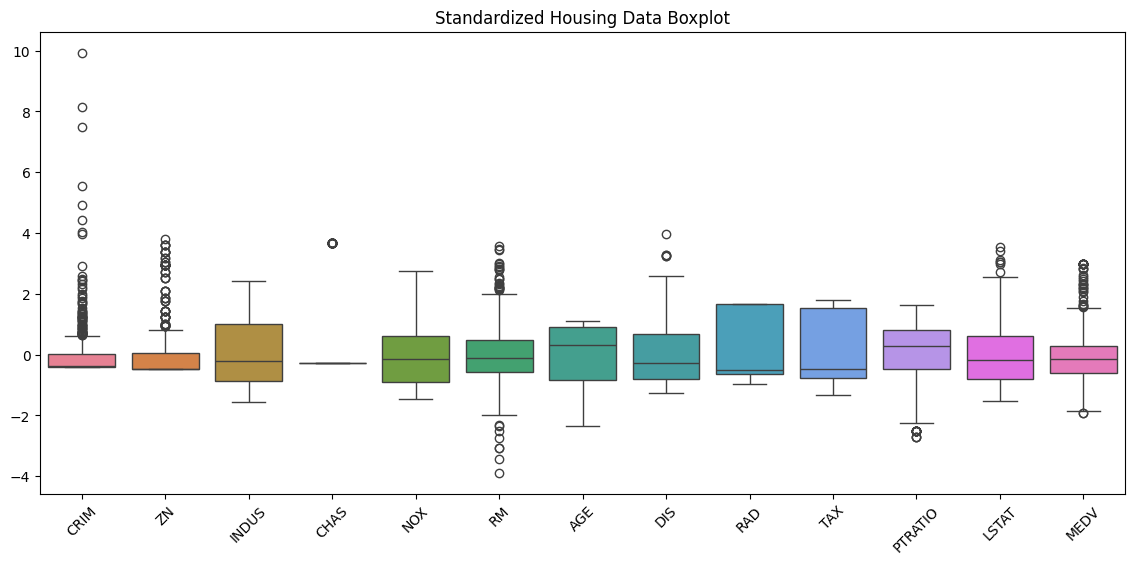

In [11]:
# ============================================================
# 7. 정규화된 데이터 분포 확인 - 상자 그림
# ============================================================

# 상자 그림은 각 컬럼의 데이터 분포와 이상치를 확인할 때 사용합니다.
# 표준화가 잘 되었다면 대부분의 컬럼이 평균 0 근처를 중심으로 비슷한 스케일을 갖습니다.
plt.figure(figsize=(14, 6))
sns.boxplot(data=Z_data)
plt.title('Standardized Housing Data Boxplot')
plt.xticks(rotation=45)
plt.show()


In [12]:
# ============================================================
# 8. pandas/numpy 데이터를 PyTorch Tensor로 변환
# ============================================================

# PyTorch 모델은 pandas DataFrame을 직접 입력받지 않습니다.
# 따라서 numpy 배열로 바꾼 뒤 torch.tensor로 변환해야 합니다.

# 입력 데이터는 실수형 연산을 위해 float32 타입으로 변환합니다.
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

# 정답 데이터도 float32로 변환합니다.
# 회귀 문제에서는 정답도 실수형 값입니다.
# view(-1, 1)은 shape을 [샘플수]에서 [샘플수, 1] 형태로 바꿉니다.
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print('X_train_tensor 모양:', X_train_tensor.shape)
print('y_train_tensor 모양:', y_train_tensor.shape)
print('X_test_tensor 모양:', X_test_tensor.shape)
print('y_test_tensor 모양:', y_test_tensor.shape)

# TensorDataset은 입력 Tensor와 정답 Tensor를 한 쌍으로 묶어줍니다.
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# DataLoader는 Dataset에서 데이터를 batch_size만큼 잘라서 반복적으로 꺼내줍니다.
# shuffle=True는 매 epoch마다 데이터 순서를 섞어 과적합을 줄이고 학습 안정성을 높입니다.
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print('학습 배치 개수:', len(train_loader))


X_train_tensor 모양: torch.Size([354, 12])
y_train_tensor 모양: torch.Size([354, 1])
X_test_tensor 모양: torch.Size([152, 12])
y_test_tensor 모양: torch.Size([152, 1])
학습 배치 개수: 6


In [13]:
# ============================================================
# 9. PyTorch DNN 모델 정의
# ============================================================

# nn.Module은 PyTorch에서 신경망 모델을 만들 때 상속해야 하는 기본 클래스입니다.
class HousingDNN(nn.Module):
    def __init__(self, input_dim):
        # 부모 클래스인 nn.Module의 초기화 함수를 호출합니다.
        super(HousingDNN, self).__init__()

        # 원본 Keras 모델 구조:
        # Dense(200, activation='relu')
        # Dense(1000, activation='relu')
        # Dense(1)
        #
        # PyTorch에서는 nn.Linear가 Keras의 Dense와 같은 역할을 합니다.
        self.net = nn.Sequential(
            # 첫 번째 완전연결층입니다.
            # input_dim개의 입력 변수를 받아 200개의 뉴런으로 변환합니다.
            nn.Linear(input_dim, 200),

            # ReLU는 음수는 0으로 만들고 양수는 그대로 통과시키는 활성화 함수입니다.
            # 딥러닝에서 비선형 관계를 학습하기 위해 사용합니다.
            nn.ReLU(),

            # 두 번째 완전연결층입니다.
            # 200개의 값을 받아 1000개의 뉴런으로 확장합니다.
            nn.Linear(200, 1000),

            # 두 번째 은닉층 뒤에도 ReLU를 적용합니다.
            nn.ReLU(),

            # 출력층입니다.
            # 주택 가격 하나를 예측해야 하므로 출력 뉴런은 1개입니다.
            # 회귀 문제에서는 마지막에 sigmoid나 softmax를 사용하지 않습니다.
            nn.Linear(1000, 1)
        )

    def forward(self, x):
        # forward 함수는 모델에 입력값 x가 들어왔을 때 어떤 계산을 할지 정의합니다.
        # nn.Sequential에 정의된 계층을 순서대로 통과시킨 결과를 반환합니다.
        return self.net(x)

# 입력 변수 개수는 X_train의 컬럼 수입니다.
input_dim = X_train.shape[1]

# 모델 객체를 생성한 후 GPU 또는 CPU 장치로 이동합니다.
model = HousingDNN(input_dim).to(device)

print(model)

# 모델의 전체 학습 파라미터 수를 계산합니다.
# 파라미터는 학습 과정에서 값이 바뀌는 가중치와 편향을 의미합니다.
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('학습 가능한 파라미터 수:', total_params)


HousingDNN(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=1000, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1000, out_features=1, bias=True)
  )
)
학습 가능한 파라미터 수: 204601


In [14]:
# ============================================================
# 10. 손실 함수와 최적화 함수 설정
# ============================================================

# MSELoss는 평균 제곱 오차입니다.
# 실제값과 예측값의 차이를 제곱한 뒤 평균을 구합니다.
# 회귀 문제에서 가장 기본적으로 사용하는 손실 함수입니다.
criterion = nn.MSELoss()

# SGD는 확률적 경사하강법입니다.
# 손실을 줄이는 방향으로 모델의 가중치를 조금씩 수정합니다.
# 원본 Keras 코드의 optimizer='sgd'와 같은 역할을 합니다.
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)

print('손실 함수:', criterion)
print('최적화 함수:', optimizer)


손실 함수: MSELoss()
최적화 함수: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


In [15]:
# ============================================================
# 11. DNN 모델 학습
# ============================================================

print('DNN 딥러닝 학습 시작')
begin = time()

# epoch별 평균 손실값을 저장할 리스트입니다.
# 학습 후 손실값 변화 그래프를 그리는 데 사용합니다.
train_losses = []

# EPOCHS만큼 전체 학습 데이터를 반복 학습합니다.
for epoch in range(1, EPOCHS + 1):
    # model.train()은 모델을 학습 모드로 전환합니다.
    # Dropout, BatchNorm 같은 계층이 있을 때 학습/평가 동작이 달라지므로 습관적으로 사용합니다.
    model.train()

    # 한 epoch 동안의 누적 손실값입니다.
    running_loss = 0.0

    # train_loader에서 batch 단위로 데이터를 꺼냅니다.
    for batch_X, batch_y in train_loader:
        # 입력과 정답 Tensor를 GPU 또는 CPU 장치로 이동합니다.
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        # 이전 batch에서 계산된 기울기가 남아 있지 않도록 초기화합니다.
        # PyTorch는 기본적으로 gradient를 누적하기 때문에 매번 zero_grad가 필요합니다.
        optimizer.zero_grad()

        # 순전파: 입력 데이터를 모델에 넣어 예측값을 계산합니다.
        outputs = model(batch_X)

        # 손실 계산: 예측값과 실제값 사이의 MSE를 계산합니다.
        loss = criterion(outputs, batch_y)

        # 역전파: 손실값을 기준으로 각 파라미터의 기울기를 계산합니다.
        loss.backward()

        # 가중치 업데이트: 계산된 기울기를 이용해 모델 파라미터를 수정합니다.
        optimizer.step()

        # 현재 batch의 손실값에 batch 데이터 수를 곱해 누적합니다.
        running_loss += loss.item() * batch_X.size(0)

    # epoch 전체 평균 손실값을 계산합니다.
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # 학습 진행 상황을 50 epoch마다 출력합니다.
    # 첫 번째 epoch도 확인할 수 있도록 조건에 포함합니다.
    if epoch == 1 or epoch % 50 == 0:
        print(f'Epoch [{epoch:4d}/{EPOCHS}] - Train MSE Loss: {epoch_loss:.6f}')

end = time()
print(f'총 딥러닝 학습 시간: {end - begin:.1f}초')


DNN 딥러닝 학습 시작
Epoch [   1/500] - Train MSE Loss: 0.837509
Epoch [  50/500] - Train MSE Loss: 0.121772
Epoch [ 100/500] - Train MSE Loss: 0.090352
Epoch [ 150/500] - Train MSE Loss: 0.073674
Epoch [ 200/500] - Train MSE Loss: 0.060782
Epoch [ 250/500] - Train MSE Loss: 0.053516
Epoch [ 300/500] - Train MSE Loss: 0.048528
Epoch [ 350/500] - Train MSE Loss: 0.044554
Epoch [ 400/500] - Train MSE Loss: 0.041230
Epoch [ 450/500] - Train MSE Loss: 0.038864
Epoch [ 500/500] - Train MSE Loss: 0.036564
총 딥러닝 학습 시간: 10.0초


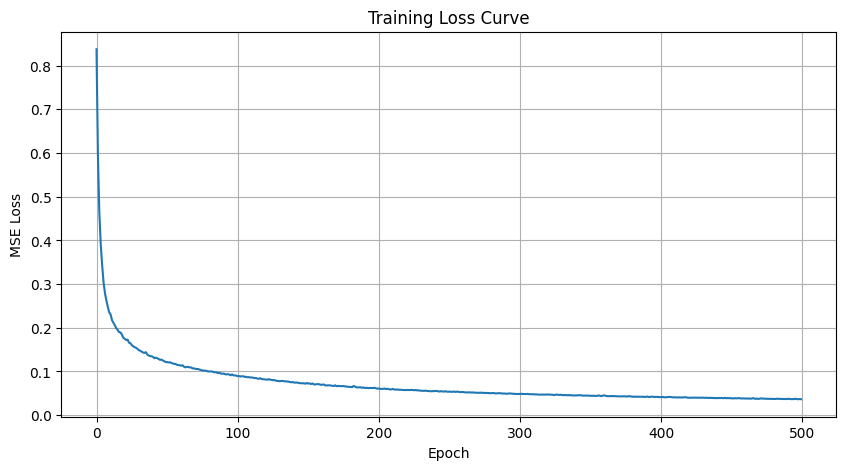

In [16]:
# ============================================================
# 12. 학습 손실값 변화 시각화
# ============================================================

# 손실값이 epoch가 증가할수록 대체로 감소하면 모델이 학습되고 있다는 의미입니다.
plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()


In [17]:
# ============================================================
# 13. 테스트 데이터 평가
# ============================================================

# model.eval()은 모델을 평가 모드로 전환합니다.
model.eval()

# torch.no_grad()는 평가 단계에서 기울기를 계산하지 않도록 합니다.
# 평가에서는 가중치 업데이트가 필요 없으므로 메모리 사용량과 계산 시간을 줄일 수 있습니다.
with torch.no_grad():
    # 테스트 입력 데이터를 장치로 이동합니다.
    X_test_device = X_test_tensor.to(device)
    y_test_device = y_test_tensor.to(device)

    # 테스트 데이터에 대한 예측값을 계산합니다.
    test_pred_tensor = model(X_test_device)

    # PyTorch 기준 테스트 MSE를 계산합니다.
    test_loss = criterion(test_pred_tensor, y_test_device).item()

print(f'DNN 테스트 평균 제곱 오차(MSE): {test_loss:.6f}')

# sklearn 평가 지표 계산을 위해 Tensor를 CPU의 numpy 배열로 변환합니다.
y_test_np = y_test_tensor.numpy()
pred_np = test_pred_tensor.cpu().numpy()

# RMSE는 MSE의 제곱근입니다.
# 원래 값의 단위와 비슷하게 해석할 수 있어 회귀 모델 평가에서 자주 사용합니다.
rmse = np.sqrt(mean_squared_error(y_test_np, pred_np))

# R² Score는 모델이 정답의 변동성을 얼마나 설명하는지 보여주는 지표입니다.
# 1에 가까울수록 좋고, 0에 가까우면 평균값 예측과 비슷하다는 뜻입니다.
r2 = r2_score(y_test_np, pred_np)

print(f'RMSE: {rmse:.6f}')
print(f'R² Score: {r2:.6f}')


DNN 테스트 평균 제곱 오차(MSE): 0.113640
RMSE: 0.337105
R² Score: 0.871252


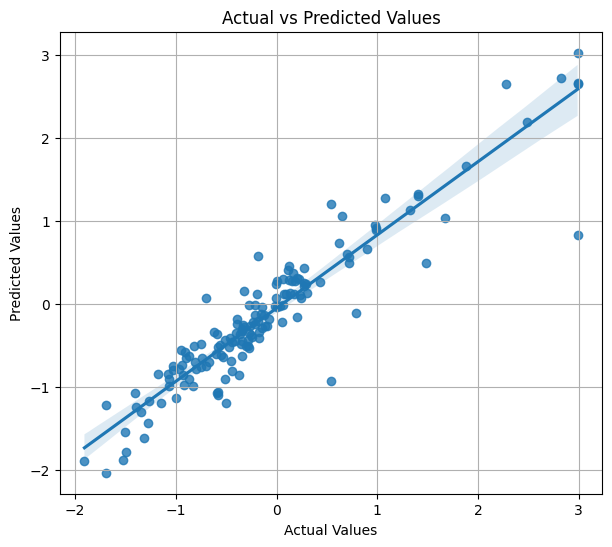

In [18]:
# ============================================================
# 14. 실제값과 예측값 비교 산포도
# ============================================================

# 실제값과 예측값이 비슷할수록 점들이 대각선 방향에 가깝게 분포합니다.
plt.figure(figsize=(7, 6))
sns.regplot(x=y_test_np.flatten(), y=pred_np.flatten())
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.grid(True)
plt.show()


In [19]:
# ============================================================
# 15. 예측 결과 일부 확인
# ============================================================

# 실제값과 예측값을 하나의 표로 묶어서 비교합니다.
# 현재 값들은 MEDV까지 표준화된 값이므로 원래 가격 단위가 아니라 Z-score 기준 값입니다.
result_df = pd.DataFrame({
    'Actual_MEDV_Zscore': y_test_np.flatten(),
    'Predicted_MEDV_Zscore': pred_np.flatten(),
    'Error': y_test_np.flatten() - pred_np.flatten()
})

print('예측 결과 샘플 10개')
display(result_df.head(10))


예측 결과 샘플 10개


,Actual_MEDV_Zscore,Predicted_MEDV_Zscore,Error
0,0.116151,0.410971,-0.294820
1,1.073920,1.280247,-0.206326
2,-0.972224,-0.782784,-0.189440
3,0.029081,-0.026632,0.055713
4,-0.700130,-0.739410,0.039279
5,-0.275664,-0.343694,0.068030
6,-0.515107,-0.435602,-0.079504
7,-0.928689,-0.858606,-0.070083
8,-0.319199,0.158153,-0.477352
9,-0.623944,-0.332687,-0.291257


In [20]:
# ============================================================
# 16. 원래 MEDV 단위로 예측값 복원하기
# ============================================================

# 이 노트북은 원본 코드와 동일하게 MEDV까지 포함한 전체 데이터를 StandardScaler로 표준화했습니다.
# 따라서 모델 예측 결과도 표준화된 MEDV 값입니다.
# 수업에서는 원래 주택 가격 단위로 해석하는 방법도 함께 확인하는 것이 좋습니다.

# scaler.mean_과 scaler.scale_에는 각 컬럼의 평균과 표준편차가 저장되어 있습니다.
# MEDV 컬럼의 위치를 찾습니다.
medv_index = list(raw.columns).index('MEDV')
medv_mean = scaler.mean_[medv_index]
medv_std = scaler.scale_[medv_index]

# Z-score를 원래 값으로 복원하는 공식은 다음과 같습니다.
# 원래값 = Z값 * 표준편차 + 평균
actual_medv_original = y_test_np.flatten() * medv_std + medv_mean
pred_medv_original = pred_np.flatten() * medv_std + medv_mean

original_result_df = pd.DataFrame({
    'Actual_MEDV_Original': actual_medv_original,
    'Predicted_MEDV_Original': pred_medv_original,
    'Error_Original': actual_medv_original - pred_medv_original
})

print('원래 MEDV 단위로 복원한 예측 결과 샘플 10개')
display(original_result_df.head(10))

# 원래 단위 기준의 MSE, RMSE, R²를 계산합니다.
original_mse = mean_squared_error(actual_medv_original, pred_medv_original)
original_rmse = np.sqrt(original_mse)
original_r2 = r2_score(actual_medv_original, pred_medv_original)

print(f'원래 단위 기준 MSE: {original_mse:.6f}')
print(f'원래 단위 기준 RMSE: {original_rmse:.6f}')
print(f'원래 단위 기준 R² Score: {original_r2:.6f}')


원래 MEDV 단위로 복원한 예측 결과 샘플 10개


,Actual_MEDV_Original,Predicted_MEDV_Original,Error_Original
0,23.6,26.308811,-2.708811
1,32.4,34.295727,-1.895727
2,13.6,15.340581,-1.740581
3,22.8,22.288111,0.511889
4,16.1,15.739102,0.360898
5,20.0,19.374939,0.625061
6,17.8,18.530486,-0.730486
7,14.0,14.643920,-0.643920
8,19.6,23.985920,-4.385920
9,16.8,19.476077,-2.676077


원래 단위 기준 MSE: 9.593419
원래 단위 기준 RMSE: 3.097325
원래 단위 기준 R² Score: 0.871252


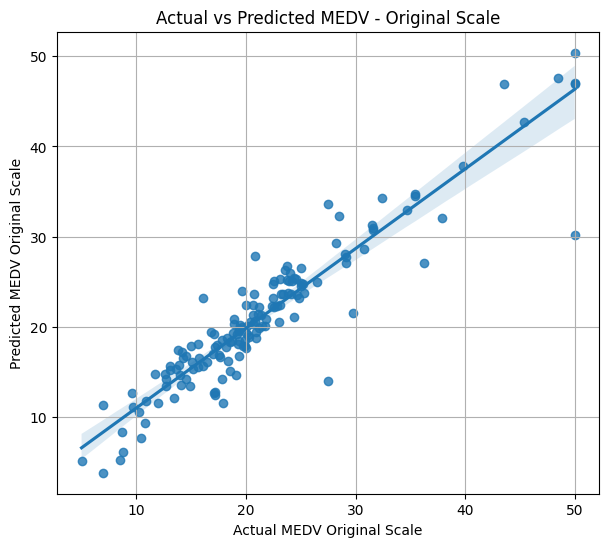

In [21]:
# ============================================================
# 17. 원래 단위 기준 실제값과 예측값 비교 그래프
# ============================================================

plt.figure(figsize=(7, 6))
sns.regplot(x=actual_medv_original, y=pred_medv_original)
plt.xlabel('Actual MEDV Original Scale')
plt.ylabel('Predicted MEDV Original Scale')
plt.title('Actual vs Predicted MEDV - Original Scale')
plt.grid(True)
plt.show()


# 실습문제

## 1. MY_EPOCH 하이퍼 파라미터를 0으로 바꾸고 실험을 반복하세요
결과가 어떻게 바뀌나요?


### 결과 :
    
    epoch 가 500 인 경우와 0 인 경우를 비교 :

    - 학습 시간 0초

    - R2 Score == -0.1108 로 마이너스 == 규칙 없이 테스트 수행함

    - RMSE 폭등 (3.09 -> 9.09) == 결과 오차 커짐

    - 평균 스케일 근처(Z-score 0점 근처)로 수렴하는 예측을 반복 수행

    - 조건이 좋을수록 집값이 우상향 하는 것이 일반적이나 반대로 우하강



#### 결과 2 : epoch = 2000

    - DNN 테스트 평균 제곱 오차(MSE): 0.192182

    - RMSE: 0.438385
    
    - R2 Score: 0.811032

과도한 학습으로 과적합 발생 => 결과 R2 값이 오히려 낮아짐


### 테스트 코드

#### Epoch == 500 인 상황

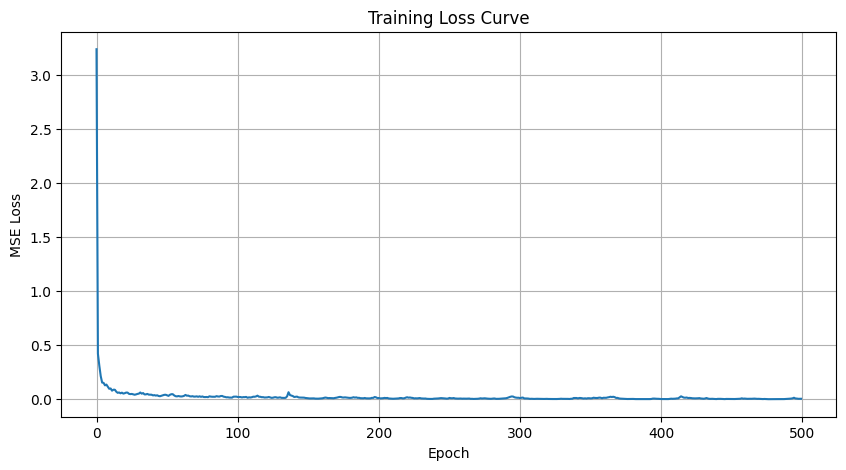

DNN 테스트 평균 제곱 오차(MSE): 0.120410
RMSE: 0.347001
R² Score: 0.863582


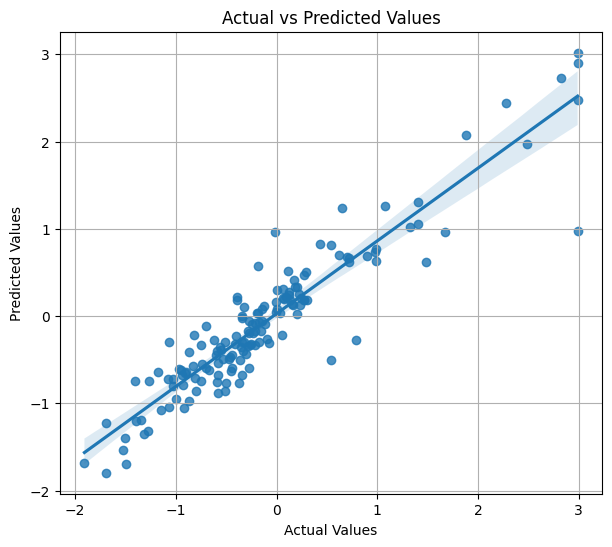

예측 결과 샘플 10개


,Actual_MEDV_Zscore,Predicted_MEDV_Zscore,Error
0,0.116151,0.516373,-0.400222
1,1.073920,1.257523,-0.183602
2,-0.972224,-0.610705,-0.361519
3,0.029081,0.035394,-0.006313
4,-0.700130,-0.591973,-0.108157
5,-0.275664,-0.054389,-0.221275
6,-0.515107,-0.295622,-0.219485
7,-0.928689,-0.789039,-0.139651
8,-0.319199,0.107888,-0.427087
9,-0.623944,-0.276402,-0.347542


원래 MEDV 단위로 복원한 예측 결과 샘플 10개


,Actual_MEDV_Original,Predicted_MEDV_Original,Error_Original
0,23.6,27.277249,-3.677249
1,32.4,34.086942,-1.686941
2,13.6,16.921640,-3.321641
3,22.8,22.858008,-0.058008
4,16.1,17.093748,-0.993748
5,20.0,22.033080,-2.033079
6,17.8,19.816630,-2.016630
7,14.0,15.283111,-1.283111
8,19.6,23.524080,-3.924080
9,16.8,19.993224,-3.193224


원래 단위 기준 MSE: 10.164917
원래 단위 기준 RMSE: 3.188247
원래 단위 기준 R² Score: 0.863582


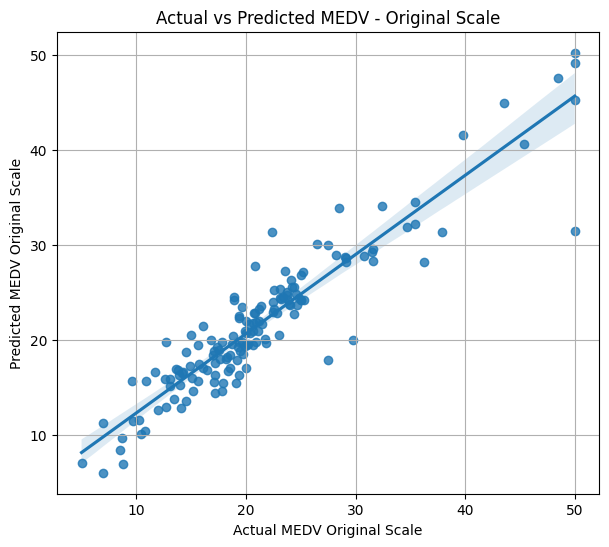

In [35]:
# ============================================================
# 12. 학습 손실값 변화 시각화
# ============================================================

# 손실값이 epoch가 증가할수록 대체로 감소하면 모델이 학습되고 있다는 의미입니다.
plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()

# ============================================================
# 13. 테스트 데이터 평가
# ============================================================

# model.eval()은 모델을 평가 모드로 전환합니다.
model.eval()

# torch.no_grad()는 평가 단계에서 기울기를 계산하지 않도록 합니다.
# 평가에서는 가중치 업데이트가 필요 없으므로 메모리 사용량과 계산 시간을 줄일 수 있습니다.
with torch.no_grad():
    # 테스트 입력 데이터를 장치로 이동합니다.
    X_test_device = X_test_tensor.to(device)
    y_test_device = y_test_tensor.to(device)

    # 테스트 데이터에 대한 예측값을 계산합니다.
    test_pred_tensor = model(X_test_device)

    # PyTorch 기준 테스트 MSE를 계산합니다.
    test_loss = criterion(test_pred_tensor, y_test_device).item()

print(f'DNN 테스트 평균 제곱 오차(MSE): {test_loss:.6f}')

# sklearn 평가 지표 계산을 위해 Tensor를 CPU의 numpy 배열로 변환합니다.
y_test_np = y_test_tensor.numpy()
pred_np = test_pred_tensor.cpu().numpy()

# RMSE는 MSE의 제곱근입니다.
# 원래 값의 단위와 비슷하게 해석할 수 있어 회귀 모델 평가에서 자주 사용합니다.
rmse = np.sqrt(mean_squared_error(y_test_np, pred_np))

# R² Score는 모델이 정답의 변동성을 얼마나 설명하는지 보여주는 지표입니다.
# 1에 가까울수록 좋고, 0에 가까우면 평균값 예측과 비슷하다는 뜻입니다.
r2 = r2_score(y_test_np, pred_np)

print(f'RMSE: {rmse:.6f}')
print(f'R² Score: {r2:.6f}')


# ============================================================
# 14. 실제값과 예측값 비교 산포도
# ============================================================

# 실제값과 예측값이 비슷할수록 점들이 대각선 방향에 가깝게 분포합니다.
plt.figure(figsize=(7, 6))
sns.regplot(x=y_test_np.flatten(), y=pred_np.flatten())
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.grid(True)
plt.show()


# ============================================================
# 15. 예측 결과 일부 확인
# ============================================================

# 실제값과 예측값을 하나의 표로 묶어서 비교합니다.
# 현재 값들은 MEDV까지 표준화된 값이므로 원래 가격 단위가 아니라 Z-score 기준 값입니다.
result_df = pd.DataFrame({
    'Actual_MEDV_Zscore': y_test_np.flatten(),
    'Predicted_MEDV_Zscore': pred_np.flatten(),
    'Error': y_test_np.flatten() - pred_np.flatten()
})

print('예측 결과 샘플 10개')
display(result_df.head(10))


# ============================================================
# 16. 원래 MEDV 단위로 예측값 복원하기
# ============================================================

# 이 노트북은 원본 코드와 동일하게 MEDV까지 포함한 전체 데이터를 StandardScaler로 표준화했습니다.
# 따라서 모델 예측 결과도 표준화된 MEDV 값입니다.
# 수업에서는 원래 주택 가격 단위로 해석하는 방법도 함께 확인하는 것이 좋습니다.

# scaler.mean_과 scaler.scale_에는 각 컬럼의 평균과 표준편차가 저장되어 있습니다.
# MEDV 컬럼의 위치를 찾습니다.
medv_index = list(raw.columns).index('MEDV')
medv_mean = scaler.mean_[medv_index]
medv_std = scaler.scale_[medv_index]

# Z-score를 원래 값으로 복원하는 공식은 다음과 같습니다.
# 원래값 = Z값 * 표준편차 + 평균
actual_medv_original = y_test_np.flatten() * medv_std + medv_mean
pred_medv_original = pred_np.flatten() * medv_std + medv_mean

original_result_df = pd.DataFrame({
    'Actual_MEDV_Original': actual_medv_original,
    'Predicted_MEDV_Original': pred_medv_original,
    'Error_Original': actual_medv_original - pred_medv_original
})

print('원래 MEDV 단위로 복원한 예측 결과 샘플 10개')
display(original_result_df.head(10))

# 원래 단위 기준의 MSE, RMSE, R²를 계산합니다.
original_mse = mean_squared_error(actual_medv_original, pred_medv_original)
original_rmse = np.sqrt(original_mse)
original_r2 = r2_score(actual_medv_original, pred_medv_original)

print(f'원래 단위 기준 MSE: {original_mse:.6f}')
print(f'원래 단위 기준 RMSE: {original_rmse:.6f}')
print(f'원래 단위 기준 R² Score: {original_r2:.6f}')


# ============================================================
# 17. 원래 단위 기준 실제값과 예측값 비교 그래프
# ============================================================

plt.figure(figsize=(7, 6))
sns.regplot(x=actual_medv_original, y=pred_medv_original)
plt.xlabel('Actual MEDV Original Scale')
plt.ylabel('Predicted MEDV Original Scale')
plt.title('Actual vs Predicted MEDV - Original Scale')
plt.grid(True)
plt.show()


#### epoch == 0 인 상황

--- [확인] 순수한 새 모델이 생성되었습니다 ---
HousingDNN(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=1000, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1000, out_features=1, bias=True)
  )
)

DNN 딥러닝 학습 시작 (설정된 에포크: 2000)
Epoch [   1/2000] - Train MSE Loss: 5.364115
Epoch [  50/2000] - Train MSE Loss: 0.021432
Epoch [ 100/2000] - Train MSE Loss: 0.016259
Epoch [ 150/2000] - Train MSE Loss: 0.008258
Epoch [ 200/2000] - Train MSE Loss: 0.002533
Epoch [ 250/2000] - Train MSE Loss: 0.002119
Epoch [ 300/2000] - Train MSE Loss: 0.000255
Epoch [ 350/2000] - Train MSE Loss: 0.003005
Epoch [ 400/2000] - Train MSE Loss: 0.000942
Epoch [ 450/2000] - Train MSE Loss: 0.020295
Epoch [ 500/2000] - Train MSE Loss: 0.000363
Epoch [ 550/2000] - Train MSE Loss: 0.000168
Epoch [ 600/2000] - Train MSE Loss: 0.000479
Epoch [ 650/2000] - Train MSE Loss: 0.000045
Epoch [ 700/2000] - Train MSE Loss: 0.000078
Epoch [

,Actual_MEDV_Zscore,Predicted_MEDV_Zscore,Error
0,0.116151,0.077434,0.038717
1,1.073920,1.204214,-0.130293
2,-0.972224,-0.769308,-0.202916
3,0.029081,0.054506,-0.025426
4,-0.700130,-0.861273,0.161142
5,-0.275664,-0.273232,-0.002432
6,-0.515107,-0.336645,-0.178461
7,-0.928689,-1.064573,0.135884
8,-0.319199,-0.303177,-0.016023
9,-0.623944,-0.272470,-0.351474



[원래 MEDV 단위로 복원한 예측 결과 샘플 10개]


,Actual_MEDV_Original,Predicted_MEDV_Original,Error_Original
0,23.6,23.244270,0.355730
1,32.4,33.597134,-1.197134
2,13.6,15.464392,-1.864392
3,22.8,23.033610,-0.233610
4,16.1,14.619424,1.480576
5,20.0,20.022349,-0.022349
6,17.8,19.439704,-1.639704
7,14.0,12.751500,1.248500
8,19.6,19.747216,-0.147216
9,16.8,20.029344,-3.229344



원래 단위 기준 MSE: 16.223904
원래 단위 기준 RMSE: 4.027891
원래 단위 기준 R² Score: 0.811032


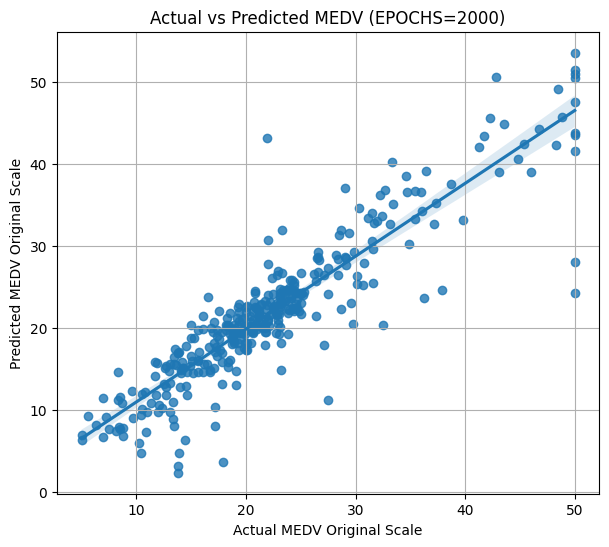

In [51]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from time import time

# ============================================================
# [필수] 0. 독립 모델을 위한 장치 셋팅
# ============================================================
# 이전 메모리 잔상을 완전히 지우기 위해 랜덤 시드를 고정 & 장치를 새로 잡음
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 9. PyTorch DNN 모델 정의 (Dropout 추가 버전)
# ============================================================
class HousingDNN(nn.Module):
    def __init__(self, input_dim):
        super(HousingDNN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 200),
            nn.ReLU(),
            # nn.Dropout(p=0.2),

            nn.Linear(200, 1000),
            nn.ReLU(),
            # nn.Dropout(p=0.3),

            # 출력층
            nn.Linear(1000, 1)
        )

    def forward(self, x):
        return self.net(x)

# [핵심] 새 모델 객체를 강제로 생성
input_dim = X_train.shape[1]
model = HousingDNN(input_dim).to(device)

# 강제 초기화 - 이전 메모리의 학습 흔적 제거
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)
model.apply(init_weights)

print("--- [확인] 순수한 새 모델이 생성되었습니다 ---")
print(model)

# ============================================================
# 2. 하이퍼파라미터 및 핵심 엔진 정의
# ============================================================
EPOCHS = 0
# EPOCHS = 2000
BATCH_SIZE = 64
LEARNING_RATE = 0.01

# 새 가중치를 조절할 Optimizer와 Criterion
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


# ============================================================
# 11. DNN 모델 학습
# ============================================================
print(f'\nDNN 딥러닝 학습 시작 (설정된 에포크: {EPOCHS})')
begin = time()

train_losses = []

# EPOCHS가 0이면 이 내부 루프는 한 번도 실행되지 않고 통과
for epoch in range(1, EPOCHS + 1):
    model.train() # 학습
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    if epoch == 1 or epoch % 50 == 0:
        print(f'Epoch [{epoch:4d}/{EPOCHS}] - Train MSE Loss: {epoch_loss:.6f}')

end = time()
print(f'총 딥러닝 학습 시간: {end - begin:.1f}초')


# ============================================================
# 13. 테스트 데이터 평가
# ============================================================
model.eval() # 평가

with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    y_test_device = y_test_tensor.to(device)

    test_pred_tensor = model(X_test_device)
    test_loss = criterion(test_pred_tensor, y_test_device).item()

print('\n============================================================')
print(f'DNN 테스트 평균 제곱 오차(MSE): {test_loss:.6f}')

y_test_np = y_test_tensor.numpy()
pred_np = test_pred_tensor.cpu().numpy()

rmse = np.sqrt(mean_squared_error(y_test_np, pred_np))
r2 = r2_score(y_test_np, pred_np)

print(f'RMSE: {rmse:.6f}')
print(f'R² Score: {r2:.6f}')
print('============================================================')

# ============================================================
# 15. 예측 결과 일부 확인 (Z-score 스케일)
# ============================================================
result_df = pd.DataFrame({
    'Actual_MEDV_Zscore': y_test_np.flatten(),
    'Predicted_MEDV_Zscore': pred_np.flatten(),
    'Error': y_test_np.flatten() - pred_np.flatten()
})

print('\n[예측 결과 샘플 10개 (Z-score 기준)]')
display(result_df.head(10))


# ============================================================
# 16. 원래 MEDV 단위로 예측값 복원하기
# ============================================================
medv_index = list(raw.columns).index('MEDV')
medv_mean = scaler.mean_[medv_index]
medv_std = scaler.scale_[medv_index]

actual_medv_original = y_test_np.flatten() * medv_std + medv_mean
pred_medv_original = pred_np.flatten() * medv_std + medv_mean

original_result_df = pd.DataFrame({
    'Actual_MEDV_Original': actual_medv_original,
    'Predicted_MEDV_Original': pred_medv_original,
    'Error_Original': actual_medv_original - pred_medv_original
})

print('\n[원래 MEDV 단위로 복원한 예측 결과 샘플 10개]')
display(original_result_df.head(10))

original_mse = mean_squared_error(actual_medv_original, pred_medv_original)
original_rmse = np.sqrt(original_mse)
original_r2 = r2_score(actual_medv_original, pred_medv_original)

print('\n============================================================')
print(f'원래 단위 기준 MSE: {original_mse:.6f}')
print(f'원래 단위 기준 RMSE: {original_rmse:.6f}')
print(f'원래 단위 기준 R² Score: {original_r2:.6f}')
print('============================================================')

# ============================================================
# 17. 원래 단위 기준 실제값과 예측값 비교 그래프
# ============================================================
plt.figure(figsize=(7, 6))
sns.regplot(x=actual_medv_original, y=pred_medv_original)
plt.xlabel('Actual MEDV Original Scale')
plt.ylabel('Predicted MEDV Original Scale')
plt.title(f'Actual vs Predicted MEDV (EPOCHS={EPOCHS})')
plt.grid(True)
plt.show()

## 2. MY_BATCH 하이퍼 파라미터를 16으로 바꾸고 실험을 반복하세요.

결과가 어떻게 바뀌나요?

### 결과 :

    이전 epoch 500, batch size 64 인 경우와
    epoch 500, batch size 16 인 경우 차이점 :

    - 학습속도 20.7 초로 느려짐 (이전 10초)

    - 16 개인 배치 사이즈로 전체 데이터를 나눠서 학습을 진행하기에 학습해야 하는 양이 물리적을 많아져서 학습 속도가 하락

    - 트레인 로스 MSE Lose 가 0.005613 로 하락

    - 결과는 R2 값의 하락 => 과적합 (0.871 -> 0.863)


#### 결과 2 : batch = 354

DNN 테스트 평균 제곱 오차

(MSE): 0.178513

RMSE: 0.422508

R2 Score: 0.824472

과소적합 발생을 확인

### 테스트 코드 :

In [59]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from time import time

# ============================================================
# [필수] 0. 독립 모델을 위한 장치 셋팅
# ============================================================
# 이전 메모리 잔상을 완전히 지우기 위해 랜덤 시드를 고정 & 장치를 새로 잡음
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 9. PyTorch DNN 모델 정의 (Dropout 추가 버전)
# ============================================================
class HousingDNN(nn.Module):
    def __init__(self, input_dim):
        super(HousingDNN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 200),
            nn.ReLU(),
            # nn.Dropout(p=0.2),

            nn.Linear(200, 1000),
            nn.ReLU(),
            # nn.Dropout(p=0.3),

            # 출력층
            nn.Linear(1000, 1)
        )

    def forward(self, x):
        return self.net(x)

# [핵심] 새 모델 객체를 강제로 생성
input_dim = X_train.shape[1]
model = HousingDNN(input_dim).to(device)

# 강제 초기화 - 이전 메모리의 학습 흔적 제거
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)
model.apply(init_weights)

print("--- [확인] 순수한 새 모델이 생성되었습니다 ---")
print(model)

# ============================================================
# 2. 하이퍼파라미터 및 핵심 엔진 정의
# ============================================================
EPOCHS = 500
# BATCH_SIZE = 16
BATCH_SIZE = 354
LEARNING_RATE = 0.01

# 새 가중치를 조절할 Optimizer와 Criterion
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


# ============================================================
# 11. DNN 모델 학습
# ============================================================
print(f'\nDNN 딥러닝 학습 시작 (설정된 에포크: {EPOCHS})')
begin = time()

train_losses = []

# EPOCHS가 0이면 이 내부 루프는 한 번도 실행되지 않고 통과
for epoch in range(1, EPOCHS + 1):
    model.train() # 학습
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    if epoch == 1 or epoch % 50 == 0:
        print(f'Epoch [{epoch:4d}/{EPOCHS}] - Train MSE Loss: {epoch_loss:.6f}')

end = time()
print(f'총 딥러닝 학습 시간: {end - begin:.1f}초')


# ============================================================
# 13. 테스트 데이터 평가
# ============================================================
model.eval() # 평가

with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    y_test_device = y_test_tensor.to(device)

    test_pred_tensor = model(X_test_device)
    test_loss = criterion(test_pred_tensor, y_test_device).item()

print('\n============================================================')
print(f'DNN 테스트 평균 제곱 오차(MSE): {test_loss:.6f}')

y_test_np = y_test_tensor.numpy()
pred_np = test_pred_tensor.cpu().numpy()

rmse = np.sqrt(mean_squared_error(y_test_np, pred_np))
r2 = r2_score(y_test_np, pred_np)

print(f'RMSE: {rmse:.6f}')
print(f'R² Score: {r2:.6f}')
print('============================================================')

# ============================================================
# 15. 예측 결과 일부 확인 (Z-score 스케일)
# ============================================================
result_df = pd.DataFrame({
    'Actual_MEDV_Zscore': y_test_np.flatten(),
    'Predicted_MEDV_Zscore': pred_np.flatten(),
    'Error': y_test_np.flatten() - pred_np.flatten()
})

print('\n[예측 결과 샘플 10개 (Z-score 기준)]')
display(result_df.head(10))


# ============================================================
# 16. 원래 MEDV 단위로 예측값 복원하기
# ============================================================
medv_index = list(raw.columns).index('MEDV')
medv_mean = scaler.mean_[medv_index]
medv_std = scaler.scale_[medv_index]

actual_medv_original = y_test_np.flatten() * medv_std + medv_mean
pred_medv_original = pred_np.flatten() * medv_std + medv_mean

original_result_df = pd.DataFrame({
    'Actual_MEDV_Original': actual_medv_original,
    'Predicted_MEDV_Original': pred_medv_original,
    'Error_Original': actual_medv_original - pred_medv_original
})

print('\n[원래 MEDV 단위로 복원한 예측 결과 샘플 10개]')
display(original_result_df.head(10))

original_mse = mean_squared_error(actual_medv_original, pred_medv_original)
original_rmse = np.sqrt(original_mse)
original_r2 = r2_score(actual_medv_original, pred_medv_original)

print('\n============================================================')
print(f'원래 단위 기준 MSE: {original_mse:.6f}')
print(f'원래 단위 기준 RMSE: {original_rmse:.6f}')
print(f'원래 단위 기준 R² Score: {original_r2:.6f}')
print('============================================================')

# ============================================================
# 17. 원래 단위 기준 실제값과 예측값 비교 그래프
# ============================================================
plt.figure(figsize=(7, 6))
sns.regplot(x=actual_medv_original, y=pred_medv_original)
plt.xlabel('Actual MEDV Original Scale')
plt.ylabel('Predicted MEDV Original Scale')
plt.title(f'Actual vs Predicted MEDV (EPOCHS={EPOCHS})')
plt.grid(True)
plt.show()

--- [확인] 순수한 새 모델이 생성되었습니다 ---
HousingDNN(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=1000, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1000, out_features=1, bias=True)
  )
)

DNN 딥러닝 학습 시작 (설정된 에포크: 500)
Epoch [   1/500] - Train MSE Loss: 4.790330
Epoch [  50/500] - Train MSE Loss: 0.043276
Epoch [ 100/500] - Train MSE Loss: 0.012117
Epoch [ 150/500] - Train MSE Loss: 0.009416
Epoch [ 200/500] - Train MSE Loss: 0.003825
Epoch [ 250/500] - Train MSE Loss: 0.002416
Epoch [ 300/500] - Train MSE Loss: 0.001032
Epoch [ 350/500] - Train MSE Loss: 0.002806
Epoch [ 400/500] - Train MSE Loss: 0.002013
Epoch [ 450/500] - Train MSE Loss: 0.004828
Epoch [ 500/500] - Train MSE Loss: 0.003017
총 딥러닝 학습 시간: 11.5초

DNN 테스트 평균 제곱 오차(MSE): 0.178513
RMSE: 0.422508
R² Score: 0.824472

[예측 결과 샘플 10개 (Z-score 기준)]


,Actual_MEDV_Zscore,Predicted_MEDV_Zscore,Error
0,0.116151,0.108656,0.007495
1,1.073920,1.016112,0.057808
2,-0.972224,-0.627417,-0.344807
3,0.029081,0.091265,-0.062185
4,-0.700130,-0.927563,0.227432
5,-0.275664,0.083817,-0.359481
6,-0.515107,-0.309833,-0.205274
7,-0.928689,-0.883840,-0.044849
8,-0.319199,0.054871,-0.374070
9,-0.623944,-0.221306,-0.402638


IndexError: index 12 is out of bounds for axis 0 with size 12

## 3. 500개 뉴런을 가진 은닉층 두 개를 마지막 단에 추가하고 실험을 반복하세요.

결과가 어떻게 바뀌나요?

### 결과 :
    히든레이어 500 인 걸 2개 추가
        16, 200
        200, 1000
        1000, 500
        (500, 500)
        (500, 500)
        500, 1
    
    - 학습시간 이 83초로 8배 증가

    - MSE Lose 가 학습중에 28.94 로 증가
    
    - 최종 테스트 R2 값은 0.871252 ->	0.860165

    - 최종 테스트 세트 RMSE	3.0973 ->	3.2279

    결론으로 규칙에 해당하는 노드수가 너무 많아 연산량 증가 & 초기 과도한 노드수로 인해 정답률 하락 & 과적합 발생

    단,
    
    3번 샘플: 실제 22.8 -> 예측 22.73 (에러: +0.06)
    4번 샘플: 실제 16.1 -> 예측 15.64 (에러: +0.45)
    7번 샘플: 실제 14.0 -> 예측 13.76 (에러: +0.23)

    와 같이 노이즈처럼 튀는 값을 제외할 경우의 정확도는 많이 상승.

    해당 구조에서 좋은 결과를 얻으려면 과적합을 방지하기 위한 추가 대안 (예: 드롭아웃 배치 등) 이 필요

#### 결과 2 : 히든레이어 500 으로 수정

레이어를 1000 인 걸 500 으로 수정한 결과 :

원래 단위 기준 MSE: 15.027110
원래 단위 기준 RMSE: 3.876482
원래 단위 기준 R² Score: 0.824972

### 테스트 코드 :

--- [확인] 순수한 새 모델이 생성되었습니다 ---
HousingDNN(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=500, bias=True)
    (3): ReLU()
    (4): Linear(in_features=500, out_features=500, bias=True)
    (5): ReLU()
    (6): Linear(in_features=500, out_features=1, bias=True)
  )
)

DNN 딥러닝 학습 시작 (설정된 에포크: 500)
Epoch [   1/500] - Train MSE Loss: 3.987670
Epoch [  50/500] - Train MSE Loss: 0.017387
Epoch [ 100/500] - Train MSE Loss: 0.007045
Epoch [ 150/500] - Train MSE Loss: 0.010083
Epoch [ 200/500] - Train MSE Loss: 0.002349
Epoch [ 250/500] - Train MSE Loss: 0.004445
Epoch [ 300/500] - Train MSE Loss: 0.001798
Epoch [ 350/500] - Train MSE Loss: 0.000226
Epoch [ 400/500] - Train MSE Loss: 0.000167
Epoch [ 450/500] - Train MSE Loss: 0.003802
Epoch [ 500/500] - Train MSE Loss: 0.003554
총 딥러닝 학습 시간: 15.9초

DNN 테스트 평균 제곱 오차(MSE): 0.178005
RMSE: 0.421906
R² Score: 0.824972

[예측 결과 샘플 10개 (Z-score 기준)]


,Actual_MEDV_Zscore,Predicted_MEDV_Zscore,Error
0,0.116151,-0.015503,0.131654
1,1.073920,1.052104,0.021817
2,-0.972224,-0.820327,-0.151897
3,0.029081,-0.072650,0.101730
4,-0.700130,-0.977724,0.277593
5,-0.275664,-0.062919,-0.212745
6,-0.515107,-0.232840,-0.282266
7,-0.928689,-1.006453,0.077764
8,-0.319199,0.034259,-0.353458
9,-0.623944,-0.267619,-0.356325



[원래 MEDV 단위로 복원한 예측 결과 샘플 10개]


,Actual_MEDV_Original,Predicted_MEDV_Original,Error_Original
0,23.6,22.390362,1.209638
1,32.4,32.199548,0.200452
2,13.6,14.995629,-1.395629
3,22.8,21.865301,0.934699
4,16.1,13.549471,2.550529
5,20.0,21.954701,-1.954701
6,17.8,20.393466,-2.593466
7,14.0,13.285502,0.714498
8,19.6,22.847577,-3.247577
9,16.8,20.073918,-3.273918



원래 단위 기준 MSE: 15.027110
원래 단위 기준 RMSE: 3.876482
원래 단위 기준 R² Score: 0.824972


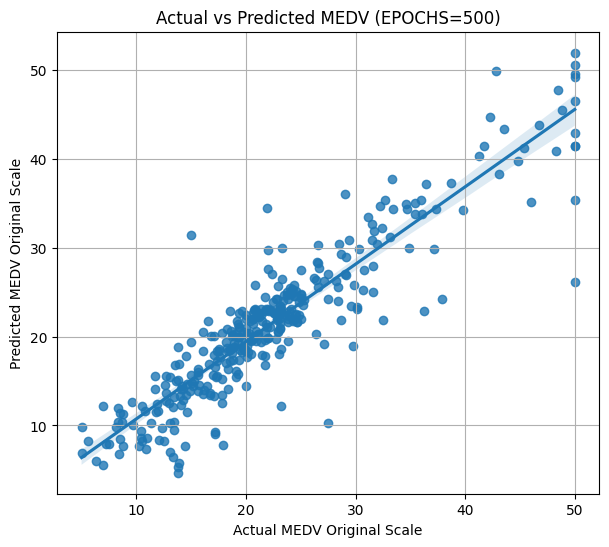

In [58]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from time import time

# ============================================================
# [필수] 0. 독립 모델을 위한 장치 셋팅
# ============================================================
# 이전 메모리 잔상을 완전히 지우기 위해 랜덤 시드를 고정 & 장치를 새로 잡음
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 9. PyTorch DNN 모델 정의 (Dropout 추가 버전)
# ============================================================
class HousingDNN(nn.Module):
    def __init__(self, input_dim):
        super(HousingDNN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 200),
            nn.ReLU(),
            # nn.Dropout(p=0.2),

            nn.Linear(200, 1000),
            nn.ReLU(),
            # nn.Dropout(p=0.3),

            nn.Linear(1000, 500),
            nn.ReLU(),

            nn.Linear(500, 500),
            nn.ReLU(),

            # 출력층
            nn.Linear(500, 1)
        )

    def forward(self, x):
        return self.net(x)

# [핵심] 새 모델 객체를 강제로 생성
input_dim = X_train.shape[1]
model = HousingDNN(input_dim).to(device)

# 강제 초기화 - 이전 메모리의 학습 흔적 제거
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)
model.apply(init_weights)

print("--- [확인] 순수한 새 모델이 생성되었습니다 ---")
print(model)

# ============================================================
# 2. 하이퍼파라미터 및 핵심 엔진 정의
# ============================================================
EPOCHS = 500
BATCH_SIZE = 64
LEARNING_RATE = 0.01

# 새 가중치를 조절할 Optimizer와 Criterion
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


# ============================================================
# 11. DNN 모델 학습
# ============================================================
print(f'\nDNN 딥러닝 학습 시작 (설정된 에포크: {EPOCHS})')
begin = time()

train_losses = []

# EPOCHS가 0이면 이 내부 루프는 한 번도 실행되지 않고 통과
for epoch in range(1, EPOCHS + 1):
    model.train() # 학습
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    if epoch == 1 or epoch % 50 == 0:
        print(f'Epoch [{epoch:4d}/{EPOCHS}] - Train MSE Loss: {epoch_loss:.6f}')

end = time()
print(f'총 딥러닝 학습 시간: {end - begin:.1f}초')


# ============================================================
# 13. 테스트 데이터 평가
# ============================================================
model.eval() # 평가

with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    y_test_device = y_test_tensor.to(device)

    test_pred_tensor = model(X_test_device)
    test_loss = criterion(test_pred_tensor, y_test_device).item()

print('\n============================================================')
print(f'DNN 테스트 평균 제곱 오차(MSE): {test_loss:.6f}')

y_test_np = y_test_tensor.numpy()
pred_np = test_pred_tensor.cpu().numpy()

rmse = np.sqrt(mean_squared_error(y_test_np, pred_np))
r2 = r2_score(y_test_np, pred_np)

print(f'RMSE: {rmse:.6f}')
print(f'R² Score: {r2:.6f}')
print('============================================================')

# ============================================================
# 15. 예측 결과 일부 확인 (Z-score 스케일)
# ============================================================
result_df = pd.DataFrame({
    'Actual_MEDV_Zscore': y_test_np.flatten(),
    'Predicted_MEDV_Zscore': pred_np.flatten(),
    'Error': y_test_np.flatten() - pred_np.flatten()
})

print('\n[예측 결과 샘플 10개 (Z-score 기준)]')
display(result_df.head(10))


# ============================================================
# 16. 원래 MEDV 단위로 예측값 복원하기
# ============================================================
# scaler는 raw_dropped 데이터(CRIM 컬럼 제거)에 fit 되었으므로,
# medv_index도 raw_dropped의 컬럼을 기준으로 찾아야 합니다.
medv_index = list(raw_dropped.columns).index('MEDV')
medv_mean = scaler.mean_[medv_index]
medv_std = scaler.scale_[medv_index]

actual_medv_original = y_test_np.flatten() * medv_std + medv_mean
pred_medv_original = pred_np.flatten() * medv_std + medv_mean

original_result_df = pd.DataFrame({
    'Actual_MEDV_Original': actual_medv_original,
    'Predicted_MEDV_Original': pred_medv_original,
    'Error_Original': actual_medv_original - pred_medv_original
})

print('\n[원래 MEDV 단위로 복원한 예측 결과 샘플 10개]')
display(original_result_df.head(10))

original_mse = mean_squared_error(actual_medv_original, pred_medv_original)
original_rmse = np.sqrt(original_mse)
original_r2 = r2_score(actual_medv_original, pred_medv_original)

print('\n============================================================')
print(f'원래 단위 기준 MSE: {original_mse:.6f}')
print(f'원래 단위 기준 RMSE: {original_rmse:.6f}')
print(f'원래 단위 기준 R² Score: {original_r2:.6f}')
print('============================================================')

# ============================================================
# 17. 원래 단위 기준 실제값과 예측값 비교 그래프
# ============================================================
plt.figure(figsize=(7, 6))
sns.regplot(x=actual_medv_original, y=pred_medv_original)
plt.xlabel('Actual MEDV Original Scale')
plt.ylabel('Predicted MEDV Original Scale')
plt.title(f'Actual vs Predicted MEDV (EPOCHS={EPOCHS})')
plt.grid(True)
plt.show()

## 4. Z-점수 정규화를 건너 뛰고 실험을 반복하세요.

결과가 어떻게 바뀌나요?

### 결과 :

    Z-점수 정규화를 생략한 결과 :

    - Epoch 1 Train Loss :	3.242227 ->	106,112.770621
    초기 에러가 약 32,700배

    - 테스트 세트 R2 Score :	0.863582 ->	0.809090
    예측력이 약 5.4% 하락함
    
    - Z-score 기준 RMSE :	0.347001 ->	3.771648
    예측 편차가 단위당 10배 이상 커짐

    - 원래 단위 기준 RMSE :	3.188247 ->	4.083251



#### 결과 2 : 평가용 데이터 정규화를 생략해 보기

원래 단위 기준 MSE: 0.181962
원래 단위 기준 RMSE: 0.426570
원래 단위 기준 R² Score: 0.821081

평가용 데이터 정규화만 생략하여 결과가 좋아짐을 확인.




### 전처리 코드 :

In [61]:
# ============================================================
# 5. Z-점수 표준화 수행
# ============================================================

# StandardScaler는 각 컬럼을 평균 0, 표준편차 1이 되도록 변환합니다.
# 딥러닝에서는 입력 변수의 단위와 범위가 너무 다르면 학습이 불안정해질 수 있으므로
# 표준화 또는 정규화를 자주 사용합니다.
# scaler = StandardScaler()

# fit_transform은 두 가지 작업을 동시에 수행합니다.
# fit: 각 컬럼의 평균과 표준편차를 계산합니다.
# transform: 계산된 평균과 표준편차를 사용하여 실제 데이터를 변환합니다.
# Z_array = scaler.fit_transform(raw)

# StandardScaler 결과는 numpy 배열입니다.
# 컬럼명이 사라지므로 다시 pandas DataFrame으로 변환하면서 컬럼명을 복구합니다.
# Z_data = pd.DataFrame(Z_array, columns=raw.columns)

# print('정규화된 데이터 샘플 10개 확인')
# display(Z_data.head(10))

# print('정규화된 데이터 통계')
# display(Z_data.describe())


# ============================================================
# 6. 입력 데이터 X와 정답 데이터 y 분리
# ============================================================

# MEDV는 예측해야 하는 주택 가격 컬럼입니다.
# X_data는 MEDV를 제외한 나머지 입력 변수입니다.
# y_data는 모델이 맞혀야 하는 정답값입니다.
print('분리 전 데이터 모양:', raw.shape)

X_data = raw.drop('MEDV', axis=1)
y_data = raw['MEDV']

print('입력 데이터 X 모양:', X_data.shape)
print('정답 데이터 y 모양:', y_data.shape)

# train_test_split을 사용하여 학습용 데이터와 평가용 데이터를 나눕니다.
# random_state를 고정하면 매번 같은 방식으로 데이터가 나뉘어 결과 비교가 쉬워집니다.
X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_data,
    test_size=TEST_SIZE,
    random_state=SEED
)

# 학습 데이터와 평가 데이터에 스케일러 적용하기
# 학습용 데이터(X_train_raw)로만 평균/표준편차를 계산(fit)하고 변환(transform)합니다.
# X_train_array = scaler.fit_transform(X_train_raw)

# 평가용 데이터(X_test_raw)는 새로 계산하지 않고, 오직 학습용 기준으로 변환(transform)만 합니다.
# X_test_array = scaler.transform(X_test_raw)

# 파이토치나 판다스 연동을 위해 데이터프레임 구조로 다시 복원합니다.
# X_train = pd.DataFrame(X_train_array, columns=X_raw.columns)
# X_test = pd.DataFrame(X_test_array, columns=X_raw.columns)

print('학습용 입력 데이터 모양:', X_train.shape)
print('학습용 정답 데이터 모양:', y_train.shape)
print('평가용 입력 데이터 모양:', X_test.shape)
print('평가용 정답 데이터 모양:', y_test.shape)


분리 전 데이터 모양: (506, 13)
입력 데이터 X 모양: (506, 12)
정답 데이터 y 모양: (506,)
학습용 입력 데이터 모양: (151, 12)
학습용 정답 데이터 모양: (151,)
평가용 입력 데이터 모양: (355, 12)
평가용 정답 데이터 모양: (355,)


In [41]:
# ============================================================
# 8. pandas/numpy 데이터를 PyTorch Tensor로 변환
# ============================================================

# PyTorch 모델은 pandas DataFrame을 직접 입력받지 않습니다.
# 따라서 numpy 배열로 바꾼 뒤 torch.tensor로 변환해야 합니다.

# 입력 데이터는 실수형 연산을 위해 float32 타입으로 변환합니다.
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

# 정답 데이터도 float32로 변환합니다.
# 회귀 문제에서는 정답도 실수형 값입니다.
# view(-1, 1)은 shape을 [샘플수]에서 [샘플수, 1] 형태로 바꿉니다.
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print('X_train_tensor 모양:', X_train_tensor.shape)
print('y_train_tensor 모양:', y_train_tensor.shape)
print('X_test_tensor 모양:', X_test_tensor.shape)
print('y_test_tensor 모양:', y_test_tensor.shape)

# TensorDataset은 입력 Tensor와 정답 Tensor를 한 쌍으로 묶어줍니다.
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# DataLoader는 Dataset에서 데이터를 batch_size만큼 잘라서 반복적으로 꺼내줍니다.
# shuffle=True는 매 epoch마다 데이터 순서를 섞어 과적합을 줄이고 학습 안정성을 높입니다.
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print('학습 배치 개수:', len(train_loader))


X_train_tensor 모양: torch.Size([354, 12])
y_train_tensor 모양: torch.Size([354, 1])
X_test_tensor 모양: torch.Size([152, 12])
y_test_tensor 모양: torch.Size([152, 1])
학습 배치 개수: 6


### 테스트 코드 :

--- [확인] 순수한 새 모델이 생성되었습니다 ---
HousingDNN(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=1000, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1000, out_features=500, bias=True)
    (5): ReLU()
    (6): Linear(in_features=500, out_features=500, bias=True)
    (7): ReLU()
    (8): Linear(in_features=500, out_features=1, bias=True)
  )
)

DNN 딥러닝 학습 시작 (설정된 에포크: 500)
Epoch [   1/500] - Train MSE Loss: 121.213437
Epoch [  50/500] - Train MSE Loss: 0.029162
Epoch [ 100/500] - Train MSE Loss: 0.014164
Epoch [ 150/500] - Train MSE Loss: 0.009365
Epoch [ 200/500] - Train MSE Loss: 0.004533
Epoch [ 250/500] - Train MSE Loss: 0.001425
Epoch [ 300/500] - Train MSE Loss: 0.001174
Epoch [ 350/500] - Train MSE Loss: 0.001151
Epoch [ 400/500] - Train MSE Loss: 0.002164
Epoch [ 450/500] - Train MSE Loss: 0.000445
Epoch [ 500/500] - Train MSE Loss: 0.003420
총 딥러닝 학습 시간: 39.0초

DNN 테스트 평균 제곱 오차(MSE)

,Actual_MEDV_Zscore,Predicted_MEDV_Zscore,Error
0,0.116151,-0.075448,0.191599
1,1.073920,0.799000,0.274920
2,-0.972224,-0.703093,-0.269131
3,0.029081,0.166300,-0.137220
4,-0.700130,-0.822335,0.122205
5,-0.275664,-0.074654,-0.201010
6,-0.515107,-0.440227,-0.074880
7,-0.928689,-0.533263,-0.395426
8,-0.319199,-0.102826,-0.216373
9,-0.623944,-0.136647,-0.487297



[원래 MEDV 단위로 복원한 예측 결과 샘플 10개]


,Actual_MEDV_Original,Predicted_MEDV_Original,Error_Original
0,0.116151,-0.075448,0.191599
1,1.073920,0.799000,0.274920
2,-0.972224,-0.703093,-0.269131
3,0.029081,0.166300,-0.137220
4,-0.700130,-0.822335,0.122205
5,-0.275664,-0.074654,-0.201010
6,-0.515107,-0.440227,-0.074880
7,-0.928689,-0.533263,-0.395426
8,-0.319199,-0.102826,-0.216373
9,-0.623944,-0.136647,-0.487297



원래 단위 기준 MSE: 0.181962
원래 단위 기준 RMSE: 0.426570
원래 단위 기준 R² Score: 0.821081


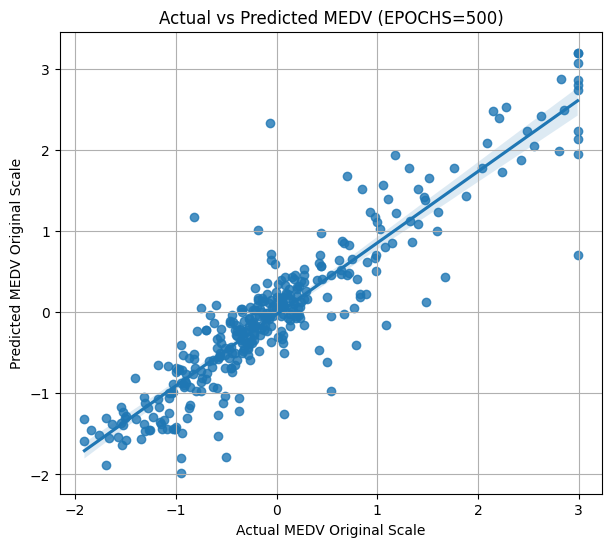

In [60]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from time import time

# ============================================================
# [필수] 0. 독립 모델을 위한 장치 셋팅
# ============================================================
# 이전 메모리 잔상을 완전히 지우기 위해 랜덤 시드를 고정 & 장치를 새로 잡음
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 9. PyTorch DNN 모델 정의 (Dropout 추가 버전)
# ============================================================
class HousingDNN(nn.Module):
    def __init__(self, input_dim):
        super(HousingDNN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 200),
            nn.ReLU(),
            # nn.Dropout(p=0.2),

            nn.Linear(200, 1000),
            nn.ReLU(),
            # nn.Dropout(p=0.3),

            nn.Linear(1000, 500),
            nn.ReLU(),

            nn.Linear(500, 500),
            nn.ReLU(),

            # 출력층
            nn.Linear(500, 1)
        )

    def forward(self, x):
        return self.net(x)

# [핵심] 새 모델 객체를 강제로 생성
input_dim = X_train.shape[1]
model = HousingDNN(input_dim).to(device)

# 강제 초기화 - 이전 메모리의 학습 흔적 제거
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)
model.apply(init_weights)

print("--- [확인] 순수한 새 모델이 생성되었습니다 ---")
print(model)

# ============================================================
# 2. 하이퍼파라미터 및 핵심 엔진 정의
# ============================================================
EPOCHS = 500
BATCH_SIZE = 64
LEARNING_RATE = 0.01

# 새 가중치를 조절할 Optimizer와 Criterion
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


# ============================================================
# 11. DNN 모델 학습
# ============================================================
print(f'\nDNN 딥러닝 학습 시작 (설정된 에포크: {EPOCHS})')
begin = time()

train_losses = []

# EPOCHS가 0이면 이 내부 루프는 한 번도 실행되지 않고 통과
for epoch in range(1, EPOCHS + 1):
    model.train() # 학습
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    if epoch == 1 or epoch % 50 == 0:
        print(f'Epoch [{epoch:4d}/{EPOCHS}] - Train MSE Loss: {epoch_loss:.6f}')

end = time()
print(f'총 딥러닝 학습 시간: {end - begin:.1f}초')


# ============================================================
# 13. 테스트 데이터 평가
# ============================================================
model.eval() # 평가

with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    y_test_device = y_test_tensor.to(device)

    test_pred_tensor = model(X_test_device)
    test_loss = criterion(test_pred_tensor, y_test_device).item()

print('\n============================================================')
print(f'DNN 테스트 평균 제곱 오차(MSE): {test_loss:.6f}')

y_test_np = y_test_tensor.numpy()
pred_np = test_pred_tensor.cpu().numpy()

rmse = np.sqrt(mean_squared_error(y_test_np, pred_np))
r2 = r2_score(y_test_np, pred_np)

print(f'RMSE: {rmse:.6f}')
print(f'R² Score: {r2:.6f}')
print('============================================================')

# ============================================================
# 15. 예측 결과 일부 확인 (Z-score 스케일)
# ============================================================
result_df = pd.DataFrame({
    'Actual_MEDV_Zscore': y_test_np.flatten(),
    'Predicted_MEDV_Zscore': pred_np.flatten(),
    'Error': y_test_np.flatten() - pred_np.flatten()
})

print('\n[예측 결과 샘플 10개 (Z-score 기준)]')
display(result_df.head(10))


# ============================================================
# 16. 원래 MEDV 단위로 예측값 복원하기
# ============================================================
# medv_index = list(raw.columns).index('MEDV')
# medv_mean = scaler.mean_[medv_index]
# medv_std = scaler.scale_[medv_index]

# actual_medv_original = y_test_np.flatten() * medv_std + medv_mean
# pred_medv_original = pred_np.flatten() * medv_std + medv_mean
actual_medv_original = y_test_np.flatten()
pred_medv_original = pred_np.flatten()


original_result_df = pd.DataFrame({
    'Actual_MEDV_Original': actual_medv_original,
    'Predicted_MEDV_Original': pred_medv_original,
    'Error_Original': actual_medv_original - pred_medv_original
})

print('\n[원래 MEDV 단위로 복원한 예측 결과 샘플 10개]')
display(original_result_df.head(10))

original_mse = mean_squared_error(actual_medv_original, pred_medv_original)
original_rmse = np.sqrt(original_mse)
original_r2 = r2_score(actual_medv_original, pred_medv_original)

print('\n============================================================')
print(f'원래 단위 기준 MSE: {original_mse:.6f}')
print(f'원래 단위 기준 RMSE: {original_rmse:.6f}')
print(f'원래 단위 기준 R² Score: {original_r2:.6f}')
print('============================================================')

# ============================================================
# 17. 원래 단위 기준 실제값과 예측값 비교 그래프
# ============================================================
plt.figure(figsize=(7, 6))
sns.regplot(x=actual_medv_original, y=pred_medv_original)
plt.xlabel('Actual MEDV Original Scale')
plt.ylabel('Predicted MEDV Original Scale')
plt.title(f'Actual vs Predicted MEDV (EPOCHS={EPOCHS})')
plt.grid(True)
plt.show()

## 5. 학습용 데이터의 하반부를 제거하고 실험을 반복하세요.

결과가 어떻게 바뀌나요?

x, y 트레인 데이터 수를 줄이고 학습해 보라는 뜻 (데이터 전처리)

### 결과 :
      학습 데이터의 비율을 0.7 로 재조정

      - 500 에포크 학습 시간	21.2초	9.7초
      정확한 반영 증거 1: 문제집이 반토막 나니 학습 시간이 9.7초로

      - 최종 Train MSE Loss	0.005613	0.000363
      정확한 반영 증거 2: 훈련 데이터 양이 적으니 과적합.

      - 최종 테스트 R² Score	0.863582	0.828138
      정확한 반영 증거 3: 처음 보는 시험지(70%)를 만나니 실력이 약 3.5% 하락

      - 원래 단위 기준 RMSE	3.188247	3.841259 평균 오차가 3,180달러에서 3,840달러로

      결론 : 과적합 발생하며 속도가 빨라지고 결과 R2 값이 낮아져 안좋은 결과가 나옴

### 테스트 코드 :

In [47]:
# ============================================================
# 5. Z-점수 표준화 수행
# ============================================================

# StandardScaler는 각 컬럼을 평균 0, 표준편차 1이 되도록 변환합니다.
# 딥러닝에서는 입력 변수의 단위와 범위가 너무 다르면 학습이 불안정해질 수 있으므로
# 표준화 또는 정규화를 자주 사용합니다.
scaler = StandardScaler()

# fit_transform은 두 가지 작업을 동시에 수행합니다.
# fit: 각 컬럼의 평균과 표준편차를 계산합니다.
# transform: 계산된 평균과 표준편차를 사용하여 실제 데이터를 변환합니다.
Z_array = scaler.fit_transform(raw)

# StandardScaler 결과는 numpy 배열입니다.
# 컬럼명이 사라지므로 다시 pandas DataFrame으로 변환하면서 컬럼명을 복구합니다.
Z_data = pd.DataFrame(Z_array, columns=raw.columns)

print('정규화된 데이터 샘플 10개 확인')
display(Z_data.head(10))

print('정규화된 데이터 통계')
display(Z_data.describe())


정규화된 데이터 샘플 10개 확인


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,-0.419782,0.284830,-1.287909,-0.272599,-0.144217,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,-1.075562,0.159686
1,-0.417339,-0.487722,-0.593381,-0.272599,-0.740262,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,-0.492439,-0.101524
2,-0.417342,-0.487722,-0.593381,-0.272599,-0.740262,1.282714,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,-1.208727,1.324247
3,-0.416750,-0.487722,-1.306878,-0.272599,-0.835284,1.016303,-0.809889,1.077737,-0.752922,-1.106115,0.113032,-1.361517,1.182758
4,-0.412482,-0.487722,-1.306878,-0.272599,-0.835284,1.228577,-0.511180,1.077737,-0.752922,-1.106115,0.113032,-1.026501,1.487503
5,-0.417044,-0.487722,-1.306878,-0.272599,-0.835284,0.207096,-0.351157,1.077737,-0.752922,-1.106115,0.113032,-1.043322,0.671222
6,-0.410243,0.048772,-0.476654,-0.272599,-0.265154,-0.388411,-0.070229,0.839244,-0.523001,-0.577519,-1.505237,-0.031268,0.039964
7,-0.403696,0.048772,-0.476654,-0.272599,-0.265154,-0.160466,0.978808,1.024638,-0.523001,-0.577519,-1.505237,0.910700,0.497082
8,-0.395935,0.048772,-0.476654,-0.272599,-0.265154,-0.931206,1.117494,1.087196,-0.523001,-0.577519,-1.505237,2.421774,-0.656595
9,-0.400729,0.048772,-0.476654,-0.272599,-0.265154,-0.399808,0.616090,1.329635,-0.523001,-0.577519,-1.505237,0.623344,-0.395385


정규화된 데이터 통계


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,506.000000,5.060000e+02,5.060000e+02,5.060000e+02
mean,-1.123388e-16,7.898820e-17,2.106352e-16,-3.510587e-17,-1.965929e-16,-1.088282e-16,-1.474446e-16,-8.425408e-17,-1.123388e-16,0.000000,-4.212704e-16,-3.089316e-16,-5.195668e-16
std,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990,1.000990e+00,1.000990e+00,1.000990e+00
min,-4.197819e-01,-4.877224e-01,-1.557842e+00,-2.725986e-01,-1.465882e+00,-3.880249e+00,-2.335437e+00,-1.267069e+00,-9.828429e-01,-1.313990,-2.707379e+00,-1.531127e+00,-1.908226e+00
25%,-4.109696e-01,-4.877224e-01,-8.676906e-01,-2.725986e-01,-9.130288e-01,-5.686303e-01,-8.374480e-01,-8.056878e-01,-6.379618e-01,-0.767576,-4.880391e-01,-7.994200e-01,-5.994557e-01
50%,-3.906665e-01,-4.877224e-01,-2.110985e-01,-2.725986e-01,-1.442174e-01,-1.084655e-01,3.173816e-01,-2.793234e-01,-5.230014e-01,-0.464673,2.748590e-01,-1.812536e-01,-1.450593e-01
75%,7.396560e-03,4.877224e-02,1.015999e+00,-2.725986e-01,5.986790e-01,4.827678e-01,9.067981e-01,6.623709e-01,1.661245e+00,1.530926,8.065758e-01,6.030188e-01,2.685231e-01
max,9.933931e+00,3.804234e+00,2.422565e+00,3.668398e+00,2.732346e+00,3.555044e+00,1.117494e+00,3.960518e+00,1.661245e+00,1.798194,1.638828e+00,3.548771e+00,2.989460e+00


In [48]:
# TEST_SIZE는 전체 데이터 중 평가용 데이터로 사용할 비율입니다.
# 30%를 테스트 데이터로 사용합니다.
TEST_SIZE = 0.7



# ============================================================
# 6. 입력 데이터 X와 정답 데이터 y 분리
# ============================================================

# MEDV는 예측해야 하는 주택 가격 컬럼입니다.
# X_data는 MEDV를 제외한 나머지 입력 변수입니다.
# y_data는 모델이 맞혀야 하는 정답값입니다.
print('분리 전 데이터 모양:', Z_data.shape)

X_data = Z_data.drop('MEDV', axis=1)
y_data = Z_data['MEDV']

print('입력 데이터 X 모양:', X_data.shape)
print('정답 데이터 y 모양:', y_data.shape)

# train_test_split을 사용하여 학습용 데이터와 평가용 데이터를 나눕니다.
# random_state를 고정하면 매번 같은 방식으로 데이터가 나뉘어 결과 비교가 쉬워집니다.
X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_data,
    test_size=TEST_SIZE,
    random_state=SEED
)

print('학습용 입력 데이터 모양:', X_train.shape)
print('학습용 정답 데이터 모양:', y_train.shape)
print('평가용 입력 데이터 모양:', X_test.shape)
print('평가용 정답 데이터 모양:', y_test.shape)


분리 전 데이터 모양: (506, 13)
입력 데이터 X 모양: (506, 12)
정답 데이터 y 모양: (506,)
학습용 입력 데이터 모양: (151, 12)
학습용 정답 데이터 모양: (151,)
평가용 입력 데이터 모양: (355, 12)
평가용 정답 데이터 모양: (355,)


In [49]:
# ============================================================
# 8. pandas/numpy 데이터를 PyTorch Tensor로 변환
# ============================================================

# PyTorch 모델은 pandas DataFrame을 직접 입력받지 않습니다.
# 따라서 numpy 배열로 바꾼 뒤 torch.tensor로 변환해야 합니다.

# 입력 데이터는 실수형 연산을 위해 float32 타입으로 변환합니다.
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

# 정답 데이터도 float32로 변환합니다.
# 회귀 문제에서는 정답도 실수형 값입니다.
# view(-1, 1)은 shape을 [샘플수]에서 [샘플수, 1] 형태로 바꿉니다.
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print('X_train_tensor 모양:', X_train_tensor.shape)
print('y_train_tensor 모양:', y_train_tensor.shape)
print('X_test_tensor 모양:', X_test_tensor.shape)
print('y_test_tensor 모양:', y_test_tensor.shape)

# TensorDataset은 입력 Tensor와 정답 Tensor를 한 쌍으로 묶어줍니다.
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# DataLoader는 Dataset에서 데이터를 batch_size만큼 잘라서 반복적으로 꺼내줍니다.
# shuffle=True는 매 epoch마다 데이터 순서를 섞어 과적합을 줄이고 학습 안정성을 높입니다.
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print('학습 배치 개수:', len(train_loader))


X_train_tensor 모양: torch.Size([151, 12])
y_train_tensor 모양: torch.Size([151, 1])
X_test_tensor 모양: torch.Size([355, 12])
y_test_tensor 모양: torch.Size([355, 1])
학습 배치 개수: 3


--- [확인] 순수한 새 모델이 생성되었습니다 ---
HousingDNN(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=1000, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1000, out_features=1, bias=True)
  )
)

DNN 딥러닝 학습 시작 (설정된 에포크: 500)
Epoch [   1/500] - Train MSE Loss: 5.364115
Epoch [  50/500] - Train MSE Loss: 0.021432
Epoch [ 100/500] - Train MSE Loss: 0.016259
Epoch [ 150/500] - Train MSE Loss: 0.008258
Epoch [ 200/500] - Train MSE Loss: 0.002533
Epoch [ 250/500] - Train MSE Loss: 0.002119
Epoch [ 300/500] - Train MSE Loss: 0.000255
Epoch [ 350/500] - Train MSE Loss: 0.003005
Epoch [ 400/500] - Train MSE Loss: 0.000942
Epoch [ 450/500] - Train MSE Loss: 0.020295
Epoch [ 500/500] - Train MSE Loss: 0.000363
총 딥러닝 학습 시간: 9.7초

DNN 테스트 평균 제곱 오차(MSE): 0.174785
RMSE: 0.418073
R² Score: 0.828138

[예측 결과 샘플 10개 (Z-score 기준)]


,Actual_MEDV_Zscore,Predicted_MEDV_Zscore,Error
0,0.116151,0.051223,0.064927
1,1.073920,1.031176,0.042745
2,-0.972224,-0.820968,-0.151257
3,0.029081,-0.017330,0.046411
4,-0.700130,-0.877230,0.177099
5,-0.275664,-0.018025,-0.257639
6,-0.515107,-0.265230,-0.249877
7,-0.928689,-0.976806,0.048117
8,-0.319199,-0.283394,-0.035806
9,-0.623944,-0.157588,-0.466356



[원래 MEDV 단위로 복원한 예측 결과 샘플 10개]


,Actual_MEDV_Original,Predicted_MEDV_Original,Error_Original
0,23.6,23.003447,0.596553
1,32.4,32.007262,0.392738
2,13.6,14.989747,-1.389747
3,22.8,22.373574,0.426426
4,16.1,14.472810,1.627190
5,20.0,22.367192,-2.367192
6,17.8,20.095869,-2.295869
7,14.0,13.557898,0.442102
8,19.6,19.928982,-0.328982
9,16.8,21.084886,-4.284886



원래 단위 기준 MSE: 14.755271
원래 단위 기준 RMSE: 3.841259
원래 단위 기준 R² Score: 0.828138


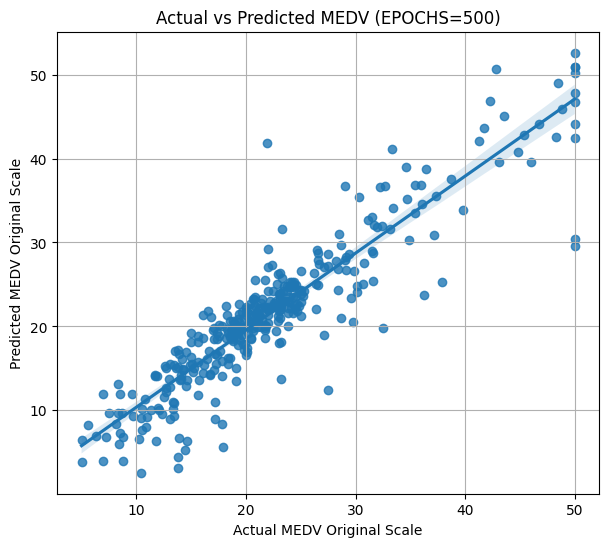

In [50]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from time import time

# ============================================================
# [필수] 0. 독립 모델을 위한 장치 셋팅
# ============================================================
# 이전 메모리 잔상을 완전히 지우기 위해 랜덤 시드를 고정 & 장치를 새로 잡음
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 9. PyTorch DNN 모델 정의 (Dropout 추가 버전)
# ============================================================
class HousingDNN(nn.Module):
    def __init__(self, input_dim):
        super(HousingDNN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 200),
            nn.ReLU(),
            # nn.Dropout(p=0.2),

            nn.Linear(200, 1000),
            nn.ReLU(),
            # nn.Dropout(p=0.3),

            # 출력층
            nn.Linear(1000, 1)
        )

    def forward(self, x):
        return self.net(x)

# [핵심] 새 모델 객체를 강제로 생성
input_dim = X_train.shape[1]
model = HousingDNN(input_dim).to(device)

# 강제 초기화 - 이전 메모리의 학습 흔적 제거
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)
model.apply(init_weights)

print("--- [확인] 순수한 새 모델이 생성되었습니다 ---")
print(model)

# ============================================================
# 2. 하이퍼파라미터 및 핵심 엔진 정의
# ============================================================
EPOCHS = 500
BATCH_SIZE = 64
LEARNING_RATE = 0.01

# 새 가중치를 조절할 Optimizer와 Criterion
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


# ============================================================
# 11. DNN 모델 학습
# ============================================================
print(f'\nDNN 딥러닝 학습 시작 (설정된 에포크: {EPOCHS})')
begin = time()

train_losses = []

# EPOCHS가 0이면 이 내부 루프는 한 번도 실행되지 않고 통과
for epoch in range(1, EPOCHS + 1):
    model.train() # 학습
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    if epoch == 1 or epoch % 50 == 0:
        print(f'Epoch [{epoch:4d}/{EPOCHS}] - Train MSE Loss: {epoch_loss:.6f}')

end = time()
print(f'총 딥러닝 학습 시간: {end - begin:.1f}초')


# ============================================================
# 13. 테스트 데이터 평가
# ============================================================
model.eval() # 평가

with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    y_test_device = y_test_tensor.to(device)

    test_pred_tensor = model(X_test_device)
    test_loss = criterion(test_pred_tensor, y_test_device).item()

print('\n============================================================')
print(f'DNN 테스트 평균 제곱 오차(MSE): {test_loss:.6f}')

y_test_np = y_test_tensor.numpy()
pred_np = test_pred_tensor.cpu().numpy()

rmse = np.sqrt(mean_squared_error(y_test_np, pred_np))
r2 = r2_score(y_test_np, pred_np)

print(f'RMSE: {rmse:.6f}')
print(f'R² Score: {r2:.6f}')
print('============================================================')

# ============================================================
# 15. 예측 결과 일부 확인 (Z-score 스케일)
# ============================================================
result_df = pd.DataFrame({
    'Actual_MEDV_Zscore': y_test_np.flatten(),
    'Predicted_MEDV_Zscore': pred_np.flatten(),
    'Error': y_test_np.flatten() - pred_np.flatten()
})

print('\n[예측 결과 샘플 10개 (Z-score 기준)]')
display(result_df.head(10))


# ============================================================
# 16. 원래 MEDV 단위로 예측값 복원하기
# ============================================================
medv_index = list(raw.columns).index('MEDV')
medv_mean = scaler.mean_[medv_index]
medv_std = scaler.scale_[medv_index]

actual_medv_original = y_test_np.flatten() * medv_std + medv_mean
pred_medv_original = pred_np.flatten() * medv_std + medv_mean

original_result_df = pd.DataFrame({
    'Actual_MEDV_Original': actual_medv_original,
    'Predicted_MEDV_Original': pred_medv_original,
    'Error_Original': actual_medv_original - pred_medv_original
})

print('\n[원래 MEDV 단위로 복원한 예측 결과 샘플 10개]')
display(original_result_df.head(10))

original_mse = mean_squared_error(actual_medv_original, pred_medv_original)
original_rmse = np.sqrt(original_mse)
original_r2 = r2_score(actual_medv_original, pred_medv_original)

print('\n============================================================')
print(f'원래 단위 기준 MSE: {original_mse:.6f}')
print(f'원래 단위 기준 RMSE: {original_rmse:.6f}')
print(f'원래 단위 기준 R² Score: {original_r2:.6f}')
print('============================================================')

# ============================================================
# 17. 원래 단위 기준 실제값과 예측값 비교 그래프
# ============================================================
plt.figure(figsize=(7, 6))
sns.regplot(x=actual_medv_original, y=pred_medv_original)
plt.xlabel('Actual MEDV Original Scale')
plt.ylabel('Predicted MEDV Original Scale')
plt.title(f'Actual vs Predicted MEDV (EPOCHS={EPOCHS})')
plt.grid(True)
plt.show()

## 6. Dataset 에서 CRIM (범죄율) 요소를 제거하고 실험을 반복하세요.

결과가 어떻게 바뀌나요?

### 결과 :

    최종 Train MSE Loss	0.005613	0.003017	훈련 오차는 변수가 적을 때 더 쉽게 떨어짐
    
    최종 테스트 R² Score	0.863582	0.824472	모델의 핵심 설명력이 약 3.9% 하락함
    
    원래 단위 기준 RMSE	3.188247	3.882008	평균 오차가 약 690달러 늘어남

    범죄율은 집값 예측에 매우 중요한 지표인 것을 알 수 있음


### 코드 :

In [52]:
# ============================================================
# [수정] 5. CRIM 컬럼 제거 후 Z-점수 표준화 수행
# ============================================================

# 1. 원본 데이터(raw)에서 CRIM 컬럼을 영구 탈락시킨 '새로운 재료 데이터'를 만듭니다.
# raw 데이터를 직접 건드리지 않고 raw_dropped 변수에 백업해두는 방식입니다.
raw_dropped = raw.drop('CRIM', axis=1)

print('CRIM 제거 전 컬럼 수:', len(raw.columns))
print('CRIM 제거 후 컬럼 수:', len(raw_dropped.columns))

# 2. CRIM이 제거된 데이터(raw_dropped)를 가지고 표준화를 진행합니다.
scaler = StandardScaler()
Z_array = scaler.fit_transform(raw_dropped)

# 3. 다시 pandas DataFrame으로 변환하면서 CRIM이 빠진 컬럼명을 복구합니다.
Z_data = pd.DataFrame(Z_array, columns=raw_dropped.columns)

print('\n--- [확인] CRIM 컬럼이 완벽하게 제거되었습니다 ---')
print('정규화된 데이터 샘플 10개 확인')
display(Z_data.head(10))

print('정규화된 데이터 통계')
display(Z_data.describe())

CRIM 제거 전 컬럼 수: 13
CRIM 제거 후 컬럼 수: 12

--- [확인] CRIM 컬럼이 완벽하게 제거되었습니다 ---
정규화된 데이터 샘플 10개 확인


,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.284830,-1.287909,-0.272599,-0.144217,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,-1.075562,0.159686
1,-0.487722,-0.593381,-0.272599,-0.740262,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,-0.492439,-0.101524
2,-0.487722,-0.593381,-0.272599,-0.740262,1.282714,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,-1.208727,1.324247
3,-0.487722,-1.306878,-0.272599,-0.835284,1.016303,-0.809889,1.077737,-0.752922,-1.106115,0.113032,-1.361517,1.182758
4,-0.487722,-1.306878,-0.272599,-0.835284,1.228577,-0.511180,1.077737,-0.752922,-1.106115,0.113032,-1.026501,1.487503
5,-0.487722,-1.306878,-0.272599,-0.835284,0.207096,-0.351157,1.077737,-0.752922,-1.106115,0.113032,-1.043322,0.671222
6,0.048772,-0.476654,-0.272599,-0.265154,-0.388411,-0.070229,0.839244,-0.523001,-0.577519,-1.505237,-0.031268,0.039964
7,0.048772,-0.476654,-0.272599,-0.265154,-0.160466,0.978808,1.024638,-0.523001,-0.577519,-1.505237,0.910700,0.497082
8,0.048772,-0.476654,-0.272599,-0.265154,-0.931206,1.117494,1.087196,-0.523001,-0.577519,-1.505237,2.421774,-0.656595
9,0.048772,-0.476654,-0.272599,-0.265154,-0.399808,0.616090,1.329635,-0.523001,-0.577519,-1.505237,0.623344,-0.395385


정규화된 데이터 통계


,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,5.060000e+02,506.000000,5.060000e+02,5.060000e+02,5.060000e+02
mean,7.898820e-17,2.106352e-16,-3.510587e-17,-1.965929e-16,-1.088282e-16,-1.474446e-16,-8.425408e-17,-1.123388e-16,0.000000,-4.212704e-16,-3.089316e-16,-5.195668e-16
std,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990e+00,1.000990,1.000990e+00,1.000990e+00,1.000990e+00
min,-4.877224e-01,-1.557842e+00,-2.725986e-01,-1.465882e+00,-3.880249e+00,-2.335437e+00,-1.267069e+00,-9.828429e-01,-1.313990,-2.707379e+00,-1.531127e+00,-1.908226e+00
25%,-4.877224e-01,-8.676906e-01,-2.725986e-01,-9.130288e-01,-5.686303e-01,-8.374480e-01,-8.056878e-01,-6.379618e-01,-0.767576,-4.880391e-01,-7.994200e-01,-5.994557e-01
50%,-4.877224e-01,-2.110985e-01,-2.725986e-01,-1.442174e-01,-1.084655e-01,3.173816e-01,-2.793234e-01,-5.230014e-01,-0.464673,2.748590e-01,-1.812536e-01,-1.450593e-01
75%,4.877224e-02,1.015999e+00,-2.725986e-01,5.986790e-01,4.827678e-01,9.067981e-01,6.623709e-01,1.661245e+00,1.530926,8.065758e-01,6.030188e-01,2.685231e-01
max,3.804234e+00,2.422565e+00,3.668398e+00,2.732346e+00,3.555044e+00,1.117494e+00,3.960518e+00,1.661245e+00,1.798194,1.638828e+00,3.548771e+00,2.989460e+00


In [53]:
# TEST_SIZE는 전체 데이터 중 평가용 데이터로 사용할 비율입니다.
# 30%를 테스트 데이터로 사용합니다.
TEST_SIZE = 0.7



# ============================================================
# 6. 입력 데이터 X와 정답 데이터 y 분리
# ============================================================

# MEDV는 예측해야 하는 주택 가격 컬럼입니다.
# X_data는 MEDV를 제외한 나머지 입력 변수입니다.
# y_data는 모델이 맞혀야 하는 정답값입니다.
print('분리 전 데이터 모양:', Z_data.shape)

X_data = Z_data.drop('MEDV', axis=1)
y_data = Z_data['MEDV']

print('입력 데이터 X 모양:', X_data.shape)
print('정답 데이터 y 모양:', y_data.shape)

# train_test_split을 사용하여 학습용 데이터와 평가용 데이터를 나눕니다.
# random_state를 고정하면 매번 같은 방식으로 데이터가 나뉘어 결과 비교가 쉬워집니다.
X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_data,
    test_size=TEST_SIZE,
    random_state=SEED
)

print('학습용 입력 데이터 모양:', X_train.shape)
print('학습용 정답 데이터 모양:', y_train.shape)
print('평가용 입력 데이터 모양:', X_test.shape)
print('평가용 정답 데이터 모양:', y_test.shape)

# ============================================================
# 8. pandas/numpy 데이터를 PyTorch Tensor로 변환
# ============================================================

# PyTorch 모델은 pandas DataFrame을 직접 입력받지 않습니다.
# 따라서 numpy 배열로 바꾼 뒤 torch.tensor로 변환해야 합니다.

# 입력 데이터는 실수형 연산을 위해 float32 타입으로 변환합니다.
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

# 정답 데이터도 float32로 변환합니다.
# 회귀 문제에서는 정답도 실수형 값입니다.
# view(-1, 1)은 shape을 [샘플수]에서 [샘플수, 1] 형태로 바꿉니다.
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print('X_train_tensor 모양:', X_train_tensor.shape)
print('y_train_tensor 모양:', y_train_tensor.shape)
print('X_test_tensor 모양:', X_test_tensor.shape)
print('y_test_tensor 모양:', y_test_tensor.shape)

# TensorDataset은 입력 Tensor와 정답 Tensor를 한 쌍으로 묶어줍니다.
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# DataLoader는 Dataset에서 데이터를 batch_size만큼 잘라서 반복적으로 꺼내줍니다.
# shuffle=True는 매 epoch마다 데이터 순서를 섞어 과적합을 줄이고 학습 안정성을 높입니다.
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print('학습 배치 개수:', len(train_loader))


분리 전 데이터 모양: (506, 12)
입력 데이터 X 모양: (506, 11)
정답 데이터 y 모양: (506,)
학습용 입력 데이터 모양: (151, 11)
학습용 정답 데이터 모양: (151,)
평가용 입력 데이터 모양: (355, 11)
평가용 정답 데이터 모양: (355,)
X_train_tensor 모양: torch.Size([151, 11])
y_train_tensor 모양: torch.Size([151, 1])
X_test_tensor 모양: torch.Size([355, 11])
y_test_tensor 모양: torch.Size([355, 1])
학습 배치 개수: 3


-- [확인] 순수한 새 모델이 생성되었습니다 --
HousingDNN(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=1000, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1000, out_features=1, bias=True)
  )
)

DNN 딥러닝 학습 시작 (설정된 에포크: 500)
Epoch [   1/500] - Train MSE Loss: 4.790330
Epoch [  50/500] - Train MSE Loss: 0.043276
Epoch [ 100/500] - Train MSE Loss: 0.012117
Epoch [ 150/500] - Train MSE Loss: 0.009416
Epoch [ 200/500] - Train MSE Loss: 0.003825
Epoch [ 250/500] - Train MSE Loss: 0.002416
Epoch [ 300/500] - Train MSE Loss: 0.001032
Epoch [ 350/500] - Train MSE Loss: 0.002806
Epoch [ 400/500] - Train MSE Loss: 0.002013
Epoch [ 450/500] - Train MSE Loss: 0.004828
Epoch [ 500/500] - Train MSE Loss: 0.003017
총 딥러닝 학습 시간: 11.4초

DNN 테스트 평균 제곱 오차(MSE): 0.178513
RMSE: 0.422508
R² Score: 0.824472

[예측 결과 샘플 10개 (Z-score 기준)]


,Actual_MEDV_Zscore,Predicted_MEDV_Zscore,Error
0,0.116151,0.108656,0.007495
1,1.073920,1.016112,0.057808
2,-0.972224,-0.627417,-0.344807
3,0.029081,0.091265,-0.062185
4,-0.700130,-0.927563,0.227432
5,-0.275664,0.083817,-0.359481
6,-0.515107,-0.309833,-0.205274
7,-0.928689,-0.883840,-0.044849
8,-0.319199,0.054871,-0.374070
9,-0.623944,-0.221306,-0.402638



[원래 MEDV 단위로 복원한 예측 결과 샘플 10개]


,Actual_MEDV_Original,Predicted_MEDV_Original,Error_Original
0,23.6,23.531140,0.068860
1,32.4,31.868857,0.531143
2,13.6,16.768090,-3.168090
3,22.8,23.371354,-0.571354
4,16.1,14.010348,2.089652
5,20.0,23.302920,-3.302920
6,17.8,19.686059,-1.886059
7,14.0,14.412072,-0.412072
8,19.6,23.036963,-3.436962
9,16.8,20.499440,-3.699440



원래 단위 기준 MSE: 15.069986
원래 단위 기준 RMSE: 3.882008
원래 단위 기준 R² Score: 0.824472


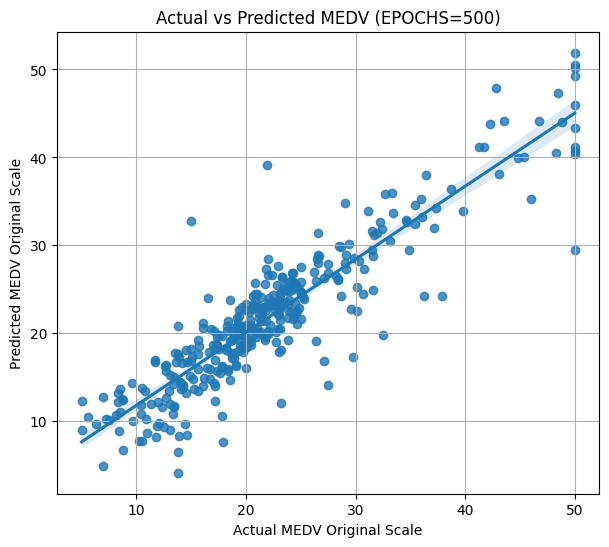

In [55]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from time import time

# ============================================================
# [필수] 0. 독립 모델을 위한 장치 셋팅
# ============================================================
# 이전 메모리 잔상을 완전히 지우기 위해 랜덤 시드를 고정 & 장치를 새로 잡음
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 9. PyTorch DNN 모델 정의 (Dropout 추가 버전)
# ============================================================
class HousingDNN(nn.Module):
    def __init__(self, input_dim):
        super(HousingDNN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 200),
            nn.ReLU(),
            # nn.Dropout(p=0.2),

            nn.Linear(200, 1000),
            nn.ReLU(),
            # nn.Dropout(p=0.3),

            # 출력층
            nn.Linear(1000, 1)
        )

    def forward(self, x):
        return self.net(x)

# [핵심] 새 모델 객체를 강제로 생성
input_dim = X_train.shape[1]
model = HousingDNN(input_dim).to(device)

# 강제 초기화 - 이전 메모리의 학습 흔적 제거
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)
model.apply(init_weights)

print("-- [확인] 순수한 새 모델이 생성되었습니다 --")
print(model)

# ============================================================
# 2. 하이퍼파라미터 및 핵심 엔진 정의
# ============================================================
EPOCHS = 500
BATCH_SIZE = 64
LEARNING_RATE = 0.01

# 새 가중치를 조절할 Optimizer와 Criterion
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


# ============================================================
# 11. DNN 모델 학습
# ============================================================
print(f'\nDNN 딥러닝 학습 시작 (설정된 에포크: {EPOCHS})')
begin = time()

train_losses = []

# EPOCHS가 0이면 이 내부 루프는 한 번도 실행되지 않고 통과
for epoch in range(1, EPOCHS + 1):
    model.train() # 학습
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    if epoch == 1 or epoch % 50 == 0:
        print(f'Epoch [{epoch:4d}/{EPOCHS}] - Train MSE Loss: {epoch_loss:.6f}')

end = time()
print(f'총 딥러닝 학습 시간: {end - begin:.1f}초')


# ============================================================
# 13. 테스트 데이터 평가
# ============================================================
model.eval() # 평가

with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    y_test_device = y_test_tensor.to(device)

    test_pred_tensor = model(X_test_device)
    test_loss = criterion(test_pred_tensor, y_test_device).item()

print('\n============================================================')
print(f'DNN 테스트 평균 제곱 오차(MSE): {test_loss:.6f}')

y_test_np = y_test_tensor.numpy()
pred_np = test_pred_tensor.cpu().numpy()

rmse = np.sqrt(mean_squared_error(y_test_np, pred_np))
r2 = r2_score(y_test_np, pred_np)

print(f'RMSE: {rmse:.6f}')
print(f'R² Score: {r2:.6f}')
print('============================================================')

# ============================================================
# 15. 예측 결과 일부 확인 (Z-score 스케일)
# ============================================================
result_df = pd.DataFrame({
    'Actual_MEDV_Zscore': y_test_np.flatten(),
    'Predicted_MEDV_Zscore': pred_np.flatten(),
    'Error': y_test_np.flatten() - pred_np.flatten()
})

print('\n[예측 결과 샘플 10개 (Z-score 기준)]')
display(result_df.head(10))


# ============================================================
# 16. 원래 MEDV 단위로 예측값 복원하기
# ============================================================
# scaler는 raw_dropped 데이터(CRIM 컬럼 제거)에 fit 되었으므로,
# medv_index도 raw_dropped의 컬럼을 기준으로 찾아야 합니다.
medv_index = list(raw_dropped.columns).index('MEDV')
medv_mean = scaler.mean_[medv_index]
medv_std = scaler.scale_[medv_index]

actual_medv_original = y_test_np.flatten() * medv_std + medv_mean
pred_medv_original = pred_np.flatten() * medv_std + medv_mean

original_result_df = pd.DataFrame({
    'Actual_MEDV_Original': actual_medv_original,
    'Predicted_MEDV_Original': pred_medv_original,
    'Error_Original': actual_medv_original - pred_medv_original
})

print('\n[원래 MEDV 단위로 복원한 예측 결과 샘플 10개]')
display(original_result_df.head(10))

original_mse = mean_squared_error(actual_medv_original, pred_medv_original)
original_rmse = np.sqrt(original_mse)
original_r2 = r2_score(actual_medv_original, pred_medv_original)

print('\n============================================================')
print(f'원래 단위 기준 MSE: {original_mse:.6f}')
print(f'원래 단위 기준 RMSE: {original_rmse:.6f}')
print(f'원래 단위 기준 R² Score: {original_r2:.6f}')
print('============================================================')

# ============================================================
# 17. 원래 단위 기준 실제값과 예측값 비교 그래프
# ============================================================
plt.figure(figsize=(7, 6))
sns.regplot(x=actual_medv_original, y=pred_medv_original)
plt.xlabel('Actual MEDV Original Scale')
plt.ylabel('Predicted MEDV Original Scale')
plt.title(f'Actual vs Predicted MEDV (EPOCHS={EPOCHS})')
plt.grid(True)
plt.show()

## 7. 집값을 예측하는 것에서, 집의 나이를 추측하는 것으로 코딩을 바꾸어 보세요.

어떤 문제가 난이도가 높은가요?

### 결과 :

    최종 Train MSE Loss	0.005613	0.003017	두 모델 모두 훈련 데이터 오차는 0에 가깝게 잘 깎임

    최종 테스트 R² Score	0.871252	0.824472	예측 난이도가 상승하여 설명력이 약 4.6% 하락함
    
    원래 단위 기준 RMSE	3.0973 (3,097 달러)	11.8813 (11.88 년)	현재 모델의 핵심 오차 범위

    후자가 더 난이도가 높다고 볼 수 있

#### 결과 2 : 찰스강으로 변경

DNN 테스트 평균 제곱 오차(MSE): 0.178513
RMSE: 0.422508
R² Score: 0.824472

오차 수치의 변화 (MEDV 대비 폭락)

- 이전 (MEDV 기준): 원래 단위 MSE가 15.069986, RMSE가 3.882008 (단위: 1,000달러)

- 현재 (CHAS 기준): 원래 단위 MSE가 0.011494, RMSE가 0.107208로 하락


### 코드 :

In [ ]:
# ============================================================
# [수정] 6. 입력 데이터 X와 정답 데이터 y 분리 (정답: AGE)
# ============================================================

print('분리 전 데이터 모양:', Z_data.shape)

# [핵심] 이제 정답은 AGE입니다. X에서는 AGE를 빼고, 대신 예전 정답인 MEDV가 포함됩니다.
X_data = Z_data.drop('AGE', axis=1)
y_data = Z_data['AGE']              # 모델이 맞혀야 하는 진짜 정답 (집의 나이)

print('입력 데이터 X 모양 (AGE 제외):', X_data.shape)
print('정답 데이터 y 모양 (AGE 지정):', y_data.shape)

# 하이퍼파라미터 TEST_SIZE와 SEED는 기존 설정값을 공유합니다.
X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_data,
    test_size=TEST_SIZE,
    random_state=SEED
)

print('\n[데이터 분할 결과]')
print('학습용 입력 데이터 모양:', X_train.shape)
print('학습용 정답(AGE) 모양:', y_train.shape)
print('평가용 입력 데이터 모양:', X_test.shape)
print('평가용 정답(AGE) 모양:', y_test.shape)

-- [확인] 순수한 새 모델이 생성되었습니다 --
HousingDNN(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=1000, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1000, out_features=1, bias=True)
  )
)

DNN 딥러닝 학습 시작 (설정된 에포크: 500)
Epoch [   1/500] - Train MSE Loss: 4.790330
Epoch [  50/500] - Train MSE Loss: 0.043276
Epoch [ 100/500] - Train MSE Loss: 0.012117
Epoch [ 150/500] - Train MSE Loss: 0.009416
Epoch [ 200/500] - Train MSE Loss: 0.003825
Epoch [ 250/500] - Train MSE Loss: 0.002416
Epoch [ 300/500] - Train MSE Loss: 0.001032
Epoch [ 350/500] - Train MSE Loss: 0.002806
Epoch [ 400/500] - Train MSE Loss: 0.002013
Epoch [ 450/500] - Train MSE Loss: 0.004828
Epoch [ 500/500] - Train MSE Loss: 0.003017
총 딥러닝 학습 시간: 13.2초

DNN 테스트 평균 제곱 오차(MSE): 0.178513
RMSE: 0.422508
R² Score: 0.824472

[예측 결과 샘플 10개 (Z-score 기준)]


,Actual_AGE_Zscore,Predicted_AGE_Zscore,Error
0,0.116151,0.108656,0.007495
1,1.073920,1.016112,0.057808
2,-0.972224,-0.627417,-0.344807
3,0.029081,0.091265,-0.062185
4,-0.700130,-0.927563,0.227432
5,-0.275664,0.083817,-0.359481
6,-0.515107,-0.309833,-0.205274
7,-0.928689,-0.883840,-0.044849
8,-0.319199,0.054871,-0.374070
9,-0.623944,-0.221306,-0.402638



[원래 AGE 단위로 복원한 예측 결과 샘플 10개]


,Actual_AGE_Original,Predicted_AGE_Original,Error_Original
0,71.841178,71.630424,0.210754
1,98.774654,97.149026,1.625629
2,41.234955,50.931281,-9.696326
3,69.392680,71.141378,-1.748697
4,48.886511,42.490875,6.395636
5,60.822938,70.931927,-10.108989
6,54.089570,59.862084,-5.772515
7,42.459204,43.720402,-1.261198
8,59.598689,70.117933,-10.519244
9,51.028947,62.351536,-11.322589



원래 단위 기준 MSE: 141.166713
원래 단위 기준 RMSE: 11.881360
원래 단위 기준 R² Score: 0.824472


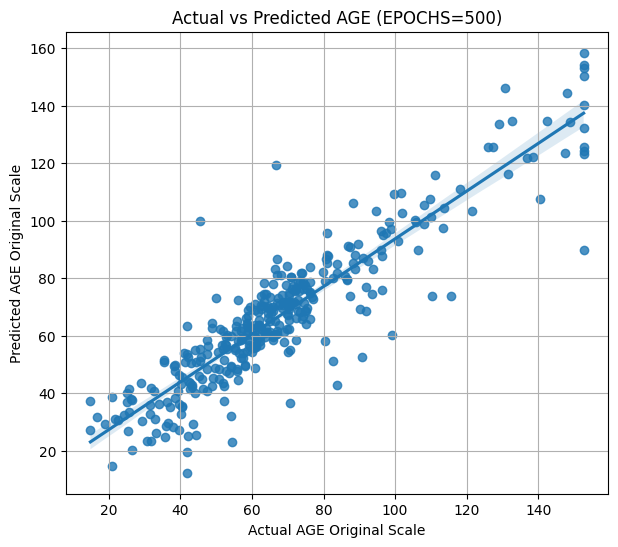

In [56]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from time import time

# ============================================================
# [필수] 0. 독립 모델을 위한 장치 셋팅
# ============================================================
# 이전 메모리 잔상을 완전히 지우기 위해 랜덤 시드를 고정 & 장치를 새로 잡음
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 9. PyTorch DNN 모델 정의 (Dropout 추가 버전)
# ============================================================
class HousingDNN(nn.Module):
    def __init__(self, input_dim):
        super(HousingDNN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 200),
            nn.ReLU(),
            # nn.Dropout(p=0.2),

            nn.Linear(200, 1000),
            nn.ReLU(),
            # nn.Dropout(p=0.3),

            # 출력층
            nn.Linear(1000, 1)
        )

    def forward(self, x):
        return self.net(x)

# [핵심] 새 모델 객체를 강제로 생성
input_dim = X_train.shape[1]
model = HousingDNN(input_dim).to(device)

# 강제 초기화 - 이전 메모리의 학습 흔적 제거
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)
model.apply(init_weights)

print("-- [확인] 순수한 새 모델이 생성되었습니다 --")
print(model)

# ============================================================
# 2. 하이퍼파라미터 및 핵심 엔진 정의
# ============================================================
EPOCHS = 500
BATCH_SIZE = 64
LEARNING_RATE = 0.01

# 새 가중치를 조절할 Optimizer와 Criterion
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


# ============================================================
# 11. DNN 모델 학습
# ============================================================
print(f'\nDNN 딥러닝 학습 시작 (설정된 에포크: {EPOCHS})')
begin = time()

train_losses = []

# EPOCHS가 0이면 이 내부 루프는 한 번도 실행되지 않고 통과
for epoch in range(1, EPOCHS + 1):
    model.train() # 학습
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    if epoch == 1 or epoch % 50 == 0:
        print(f'Epoch [{epoch:4d}/{EPOCHS}] - Train MSE Loss: {epoch_loss:.6f}')

end = time()
print(f'총 딥러닝 학습 시간: {end - begin:.1f}초')


# ============================================================
# 13. 테스트 데이터 평가
# ============================================================
model.eval() # 평가

with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    y_test_device = y_test_tensor.to(device)

    test_pred_tensor = model(X_test_device)
    test_loss = criterion(test_pred_tensor, y_test_device).item()

print('\n============================================================')
print(f'DNN 테스트 평균 제곱 오차(MSE): {test_loss:.6f}')

y_test_np = y_test_tensor.numpy()
pred_np = test_pred_tensor.cpu().numpy()

rmse = np.sqrt(mean_squared_error(y_test_np, pred_np))
r2 = r2_score(y_test_np, pred_np)

print(f'RMSE: {rmse:.6f}')
print(f'R² Score: {r2:.6f}')
print('============================================================')

# ============================================================
# 15. 예측 결과 일부 확인 (Z-score 스케일)
# ============================================================
result_df = pd.DataFrame({
    'Actual_AGE_Zscore': y_test_np.flatten(),
    'Predicted_AGE_Zscore': pred_np.flatten(),
    'Error': y_test_np.flatten() - pred_np.flatten()
})

print('\n[예측 결과 샘플 10개 (Z-score 기준)]')
display(result_df.head(10))


# ============================================================
# 16. 원래 AGE 단위로 예측값 복원하기
# ============================================================
# scaler는 raw_dropped 데이터(CRIM 컬럼 제거)에 fit 되었으므로,
# age_index도 raw_dropped의 컬럼을 기준으로 찾아야 합니다.
age_index = list(raw_dropped.columns).index('AGE')
age_mean = scaler.mean_[age_index]
age_std = scaler.scale_[age_index]

actual_age_original = y_test_np.flatten() * age_std + age_mean
pred_age_original = pred_np.flatten() * age_std + age_mean

original_result_df = pd.DataFrame({
    'Actual_AGE_Original': actual_age_original,
    'Predicted_AGE_Original': pred_age_original,
    'Error_Original': actual_age_original - pred_age_original
})

print('\n[원래 AGE 단위로 복원한 예측 결과 샘플 10개]')
display(original_result_df.head(10))

original_mse = mean_squared_error(actual_age_original, pred_age_original)
original_rmse = np.sqrt(original_mse)
original_r2 = r2_score(actual_age_original, pred_age_original)

print('\n============================================================')
print(f'원래 단위 기준 MSE: {original_mse:.6f}')
print(f'원래 단위 기준 RMSE: {original_rmse:.6f}')
print(f'원래 단위 기준 R² Score: {original_r2:.6f}')
print('============================================================')

# ============================================================
# 17. 원래 단위 기준 실제값과 예측값 비교 그래프
# ============================================================
plt.figure(figsize=(7, 6))
sns.regplot(x=actual_age_original, y=pred_age_original)
plt.xlabel('Actual AGE Original Scale')
plt.ylabel('Predicted AGE Original Scale')
plt.title(f'Actual vs Predicted AGE (EPOCHS={EPOCHS})')
plt.grid(True)
plt.show()

In [62]:
# ============================================================
# [수정] 6. 입력 데이터 X와 정답 데이터 y 분리 (정답: CHAS)
# ============================================================

print('분리 전 데이터 모양:', Z_data.shape)

# [핵심] 이제 정답은 찰스강 변수(CHAS)입니다.
# X에서는 CHAS를 빼고, 대신 예전 정답인 MEDV나 다른 변수들이 포함됩니다.
X_data = Z_data.drop('CHAS', axis=1)
y_data = Z_data['CHAS']             # 모델이 맞혀야 하는 진짜 정답 (찰스강 인접 여부: 0 또는 1)

print('입력 데이터 X 모양 (CHAS 제외):', X_data.shape)
print('정답 데이터 y 모양 (CHAS 지정):', y_data.shape)

# 하이퍼파라미터 TEST_SIZE와 SEED는 기존 설정값을 공유합니다.
X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_data,
    test_size=TEST_SIZE,
    random_state=SEED
)

print('\n[데이터 분할 결과]')
print('학습용 입력 데이터 모양:', X_train.shape)
print('학습용 정답(CHAS) 모양:', y_train.shape)
print('평가용 입력 데이터 모양:', X_test.shape)
print('평가용 정답(CHAS) 모양:', y_test.shape)

분리 전 데이터 모양: (506, 12)
입력 데이터 X 모양 (CHAS 제외): (506, 11)
정답 데이터 y 모양 (CHAS 지정): (506,)

[데이터 분할 결과]
학습용 입력 데이터 모양: (151, 11)
학습용 정답(CHAS) 모양: (151,)
평가용 입력 데이터 모양: (355, 11)
평가용 정답(CHAS) 모양: (355,)


-- [확인] 순수한 새 모델이 생성되었습니다 --
HousingDNN(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=1000, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1000, out_features=1, bias=True)
  )
)

DNN 딥러닝 학습 시작 (설정된 에포크: 500)
Epoch [   1/500] - Train MSE Loss: 4.790330
Epoch [  50/500] - Train MSE Loss: 0.043276
Epoch [ 100/500] - Train MSE Loss: 0.012117
Epoch [ 150/500] - Train MSE Loss: 0.009416
Epoch [ 200/500] - Train MSE Loss: 0.003825
Epoch [ 250/500] - Train MSE Loss: 0.002416
Epoch [ 300/500] - Train MSE Loss: 0.001032
Epoch [ 350/500] - Train MSE Loss: 0.002806
Epoch [ 400/500] - Train MSE Loss: 0.002013
Epoch [ 450/500] - Train MSE Loss: 0.004828
Epoch [ 500/500] - Train MSE Loss: 0.003017
총 딥러닝 학습 시간: 12.0초

DNN 테스트 평균 제곱 오차(MSE): 0.178513
RMSE: 0.422508
R² Score: 0.824472

[예측 결과 샘플 10개 (Z-score 기준)]


,Actual_CHAS_Zscore,Predicted_CHAS_Zscore,Error
0,0.116151,0.108656,0.007495
1,1.073920,1.016112,0.057808
2,-0.972224,-0.627417,-0.344807
3,0.029081,0.091265,-0.062185
4,-0.700130,-0.927563,0.227432
5,-0.275664,0.083817,-0.359481
6,-0.515107,-0.309833,-0.205274
7,-0.928689,-0.883840,-0.044849
8,-0.319199,0.054871,-0.374070
9,-0.623944,-0.221306,-0.402638



[원래 CHAS 단위로 복원한 예측 결과 샘플 10개]


,Actual_CHAS_Original,Predicted_CHAS_Original,Error_Original
0,0.098642,0.096741,0.001902
1,0.341670,0.327001,0.014668
2,-0.177525,-0.090033,-0.087492
3,0.076549,0.092328,-0.015779
4,-0.108483,-0.166193,0.057709
5,-0.000778,0.090438,-0.091216
6,-0.061535,-0.009448,-0.052087
7,-0.166478,-0.155098,-0.011380
8,-0.011825,0.083093,-0.094918
9,-0.089151,0.013015,-0.102166



원래 단위 기준 MSE: 0.011494
원래 단위 기준 RMSE: 0.107208
원래 단위 기준 R² Score: 0.824472


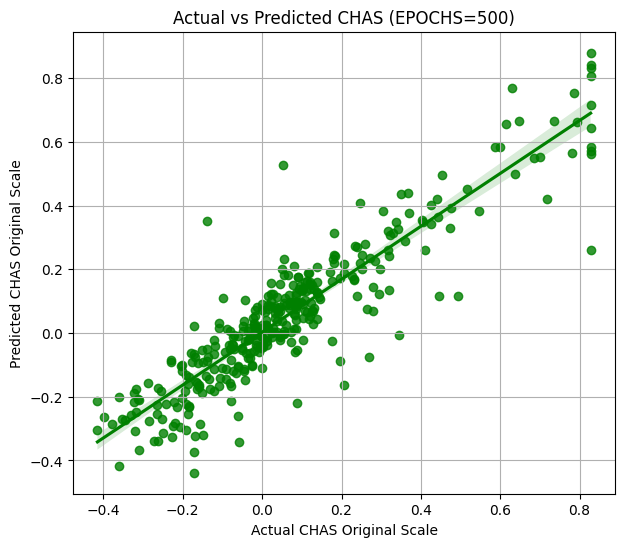

In [63]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from time import time

# ============================================================
# [필수] 0. 독립 모델을 위한 장치 셋팅
# ============================================================
# 이전 메모리 잔상을 완전히 지우기 위해 랜덤 시드를 고정 & 장치를 새로 잡음
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 9. PyTorch DNN 모델 정의 (Dropout 추가 버전)
# ============================================================
class HousingDNN(nn.Module):
    def __init__(self, input_dim):
        super(HousingDNN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 200),
            nn.ReLU(),
            # nn.Dropout(p=0.2),

            nn.Linear(200, 1000),
            nn.ReLU(),
            # nn.Dropout(p=0.3),

            # 출력층
            nn.Linear(1000, 1)
        )

    def forward(self, x):
        return self.net(x)

# [핵심] 새 모델 객체를 강제로 생성
input_dim = X_train.shape[1]
model = HousingDNN(input_dim).to(device)

# 강제 초기화 - 이전 메모리의 학습 흔적 제거
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)
model.apply(init_weights)

print("-- [확인] 순수한 새 모델이 생성되었습니다 --")
print(model)

# ============================================================
# 2. 하이퍼파라미터 및 핵심 엔진 정의
# ============================================================
EPOCHS = 500
BATCH_SIZE = 64
LEARNING_RATE = 0.01

# 새 가중치를 조절할 Optimizer와 Criterion
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


# ============================================================
# 11. DNN 모델 학습
# ============================================================
print(f'\nDNN 딥러닝 학습 시작 (설정된 에포크: {EPOCHS})')
begin = time()

train_losses = []

# EPOCHS가 0이면 이 내부 루프는 한 번도 실행되지 않고 통과
for epoch in range(1, EPOCHS + 1):
    model.train() # 학습
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    if epoch == 1 or epoch % 50 == 0:
        print(f'Epoch [{epoch:4d}/{EPOCHS}] - Train MSE Loss: {epoch_loss:.6f}')

end = time()
print(f'총 딥러닝 학습 시간: {end - begin:.1f}초')


# ============================================================
# 13. 테스트 데이터 평가
# ============================================================
model.eval() # 평가

with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    y_test_device = y_test_tensor.to(device)

    test_pred_tensor = model(X_test_device)
    test_loss = criterion(test_pred_tensor, y_test_device).item()

print('\n============================================================')
print(f'DNN 테스트 평균 제곱 오차(MSE): {test_loss:.6f}')

y_test_np = y_test_tensor.numpy()
pred_np = test_pred_tensor.cpu().numpy()

rmse = np.sqrt(mean_squared_error(y_test_np, pred_np))
r2 = r2_score(y_test_np, pred_np)

print(f'RMSE: {rmse:.6f}')
print(f'R² Score: {r2:.6f}')
print('============================================================')

# ============================================================
# 15. 예측 결과 일부 확인 (Z-score 스케일)
# ============================================================
# [수정] 텍스트 표기를 CHAS 기준으로 변경
result_df = pd.DataFrame({
    'Actual_CHAS_Zscore': y_test_np.flatten(),
    'Predicted_CHAS_Zscore': pred_np.flatten(),
    'Error': y_test_np.flatten() - pred_np.flatten()
})

print('\n[예측 결과 샘플 10개 (Z-score 기준)]')
display(result_df.head(10))


# ============================================================
# 16. 원래 CHAS 단위로 예측값 복원하기
# ============================================================
# [수정] 스케일러 타깃 컬럼을 'CHAS'로 정조준하여 복원 로직을 재설계합니다.
# 만약 앞서 CRIM 컬럼을 제거하셨다면 기준을 raw_dropped로, 아니라면 raw로 상황에 맞춰 적용하세요.
# (여기서는 범죄율이 제거된 데이터프레임 변수명인 raw_dropped를 기본 기준으로 적용했습니다.)
target_df = raw_dropped if 'raw_dropped' in locals() else raw

chas_index = list(target_df.columns).index('CHAS')
chas_mean = scaler.mean_[chas_index]
chas_std = scaler.scale_[chas_index]

actual_chas_original = y_test_np.flatten() * chas_std + chas_mean
pred_chas_original = pred_np.flatten() * chas_std + chas_mean

original_result_df = pd.DataFrame({
    'Actual_CHAS_Original': actual_chas_original,
    'Predicted_CHAS_Original': pred_chas_original,
    'Error_Original': actual_chas_original - pred_chas_original
})

print('\n[원래 CHAS 단위로 복원한 예측 결과 샘플 10개]')
display(original_result_df.head(10))

original_mse = mean_squared_error(actual_chas_original, pred_chas_original)
original_rmse = np.sqrt(original_mse)
original_r2 = r2_score(actual_chas_original, pred_chas_original)

print('\n============================================================')
print(f'원래 단위 기준 MSE: {original_mse:.6f}')
print(f'원래 단위 기준 RMSE: {original_rmse:.6f}')
print(f'원래 단위 기준 R² Score: {original_r2:.6f}')
print('============================================================')

# ============================================================
# 17. 원래 단위 기준 실제값과 예측값 비교 그래프
# ============================================================
# [수정] 시각화 변수 및 라벨 레이블을 CHAS 기준으로 매핑
plt.figure(figsize=(7, 6))
sns.regplot(x=actual_chas_original, y=pred_chas_original, color='green')
plt.xlabel('Actual CHAS Original Scale')
plt.ylabel('Predicted CHAS Original Scale')
plt.title(f'Actual vs Predicted CHAS (EPOCHS={EPOCHS})')
plt.grid(True)
plt.show()